# Imports and configs

In [65]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.spatial.transform import Rotation as R

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = ['MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import polars as pl
import warnings
import optuna
import joblib
import glob
import gc
import time
from typing import Tuple, Dict, List
from tqdm import tqdm
import os

warnings.filterwarnings("ignore")

In [3]:
class CFG:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 5
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Data loading

In [4]:
train = pd.read_csv(CFG.train_path).reset_index(drop=True)
train_d = pd.read_csv(CFG.train_demographic_path).reset_index(drop=True)
test = pd.read_csv(CFG.test_path).reset_index(drop=True)
test_d = pd.read_csv(CFG.test_demographic_path).reset_index(drop=True)

# ACC/ROT Preprocessing

In [5]:
def remove_gravity_from_acc(acc_data, rot_data):

    if isinstance(acc_data, pd.DataFrame):
        acc_values = acc_data[['acc_x', 'acc_y', 'acc_z']].values
    else:
        acc_values = acc_data

    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = acc_values.shape[0]
    linear_accel = np.zeros_like(acc_values)
    
    gravity_world = np.array([0, 0, 9.81])

    for i in range(num_samples):
        if np.all(np.isnan(quat_values[i])) or np.all(np.isclose(quat_values[i], 0)):
            linear_accel[i, :] = acc_values[i, :] 
            continue

        try:
            rotation = R.from_quat(quat_values[i])
            gravity_sensor_frame = rotation.apply(gravity_world, inverse=True)
            linear_accel[i, :] = acc_values[i, :] - gravity_sensor_frame
        except ValueError:
             linear_accel[i, :] = acc_values[i, :]
             
    return linear_accel

In [6]:
def calculate_angular_velocity_from_quat(rot_data, time_delta=1/200): # Assuming 200Hz sampling rate
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_vel = np.zeros((num_samples, 3))

    for i in range(num_samples - 1):
        q_t = quat_values[i]
        q_t_plus_dt = quat_values[i+1]

        if np.all(np.isnan(q_t)) or np.all(np.isclose(q_t, 0)) or \
           np.all(np.isnan(q_t_plus_dt)) or np.all(np.isclose(q_t_plus_dt, 0)):
            continue

        try:
            rot_t = R.from_quat(q_t)
            rot_t_plus_dt = R.from_quat(q_t_plus_dt)

            # Calculate the relative rotation
            delta_rot = rot_t.inv() * rot_t_plus_dt
            
            # Convert delta rotation to angular velocity vector
            # The rotation vector (Euler axis * angle) scaled by 1/dt
            # is a good approximation for small delta_rot
            angular_vel[i, :] = delta_rot.as_rotvec() / time_delta
        except ValueError:
            # If quaternion is invalid, angular velocity remains zero
            pass
            
    return angular_vel

In [7]:
def calculate_angular_distance(rot_data):
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_dist = np.zeros(num_samples)

    for i in range(num_samples - 1):
        q1 = quat_values[i]
        q2 = quat_values[i+1]

        if np.all(np.isnan(q1)) or np.all(np.isclose(q1, 0)) or \
           np.all(np.isnan(q2)) or np.all(np.isclose(q2, 0)):
            angular_dist[i] = 0 # Или np.nan, в зависимости от желаемого поведения
            continue
        try:
            # Преобразование кватернионов в объекты Rotation
            r1 = R.from_quat(q1)
            r2 = R.from_quat(q2)

            # Вычисление углового расстояния: 2 * arccos(|real(p * q*)|)
            # где p* - сопряженный кватернион q
            # В scipy.spatial.transform.Rotation, r1.inv() * r2 дает относительное вращение.
            # Угол этого относительного вращения - это и есть угловое расстояние.
            relative_rotation = r1.inv() * r2
            
            # Угол rotation vector соответствует угловому расстоянию
            # Норма rotation vector - это угол в радианах
            angle = np.linalg.norm(relative_rotation.as_rotvec())
            angular_dist[i] = angle
        except ValueError:
            angular_dist[i] = 0 # В случае недействительных кватернионов
            pass
            
    return angular_dist

In [8]:
def plot_acceleration_timeseries(data, gesture_name, orientation, behavior, num_sequences=5, figsize=(15, 12)):
    """
    特定のジェスチャー、方向、行動の時系列データ（加速度）を複数シーケンス重ねて表示
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム
    gesture_name : str
        表示するジェスチャー名
    orientation : str
        表示する方向（例: 'Forward', 'Backward'など）
    behavior : str
        表示する行動（例: 'Moves hand to target location'など）
    num_sequences : int or None
        表示するシーケンス数（デフォルト: 5、Noneの場合は全シーケンス）
    figsize : tuple
        図のサイズ（デフォルト: (15, 12)）
    """
    
    # 指定された条件でデータを抽出
    filtered_data = data[
        (data['gesture'] == gesture_name) & 
        (data['orientation'] == orientation) & 
        (data['behavior'] == behavior)
    ]
    
    if len(filtered_data) == 0:
        print(f"❌ ジェスチャー '{gesture_name}', 方向 '{orientation}', 行動 '{behavior}' の条件に一致するデータが見つかりません")
        # 利用可能なデータの組み合わせを表示
        available_combinations = data[data['gesture'] == gesture_name].groupby(['orientation', 'behavior']).size()
        print(f"\n利用可能な組み合わせ（ジェスチャー: {gesture_name}）:")
        for (orient, behav), count in available_combinations.items():
            print(f"  方向: {orient}, 行動: {behav} ({count} レコード)")
        return
    
    # acc_magnitudeが存在しない場合は計算
    if 'acc_magnitude' not in filtered_data.columns:
        filtered_data = filtered_data.copy()
        filtered_data['acc_magnitude'] = np.sqrt(filtered_data['acc_x']**2 + filtered_data['acc_y']**2 + filtered_data['acc_z']**2)
    
    # ユニークなsequence_idを取得
    unique_sequences = filtered_data['sequence_id'].unique()
    
    # 全シーケンス表示の場合
    if num_sequences is None:
        num_sequences = len(unique_sequences)
        sequences_to_plot = unique_sequences
    else:
        if len(unique_sequences) < num_sequences:
            print(f"⚠️ 指定された条件のシーケンスが{num_sequences}個未満です（{len(unique_sequences)}個）")
            num_sequences = len(unique_sequences)
        # 表示するシーケンスを選択
        sequences_to_plot = unique_sequences[:num_sequences]
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    behavior_text = behavior_to_text.get(behavior, behavior)
    
    # プロット用の図を作成（4つのサブプロットに変更）
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    fig.suptitle(f'{gesture_name} - {orientation} - {behavior_text} (Acceleration)', fontsize=16, fontweight='bold')
    
    # 各シーケンスをプロット
    for i, sequence_id in enumerate(sequences_to_plot):
        seq_data = filtered_data[filtered_data['sequence_id'] == sequence_id].copy()
        seq_data = seq_data.sort_values('sequence_counter')
        
        # X軸加速度
        axes[0].plot(seq_data['sequence_counter'], seq_data['acc_x'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # Y軸加速度
        axes[1].plot(seq_data['sequence_counter'], seq_data['acc_y'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # Z軸加速度
        axes[2].plot(seq_data['sequence_counter'], seq_data['acc_z'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # 加速度magnitude
        axes[3].plot(seq_data['sequence_counter'], seq_data['acc_magnitude'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
    
    # 軸の設定
    axes[0].set_ylabel('acc_x', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].set_ylabel('acc_y', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[2].set_ylabel('acc_z', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    axes[3].set_xlabel('sequence_counter', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('acc_magnitude', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print(f"\n📊 統計情報:")
    print(f"ジェスチャー: {gesture_name}")
    print(f"方向: {orientation}")
    print(f"行動: {behavior_text}")
    print(f"表示したシーケンス数: {len(sequences_to_plot)}")
    print(f"条件に一致する総シーケンス数: {len(unique_sequences)}")
    print(f"総データポイント数: {len(filtered_data)}")
    
    # 各軸の統計情報
    print(f"\n📈 加速度統計:")
    print(f"  acc_x - 平均: {filtered_data['acc_x'].mean():.4f}, 標準偏差: {filtered_data['acc_x'].std():.4f}")
    print(f"  acc_y - 平均: {filtered_data['acc_y'].mean():.4f}, 標準偏差: {filtered_data['acc_y'].std():.4f}")
    print(f"  acc_z - 平均: {filtered_data['acc_z'].mean():.4f}, 標準偏差: {filtered_data['acc_z'].std():.4f}")
    print(f"  acc_magnitude - 平均: {filtered_data['acc_magnitude'].mean():.4f}, 標準偏差: {filtered_data['acc_magnitude'].std():.4f}")

In [9]:
def plot_linear_acceleration_timeseries(data, gesture_name, orientation, behavior, num_sequences=5, figsize=(15, 12)):
    """
    特定のジェスチャー、方向、行動の時系列データ（重力除去後の線形加速度）を複数シーケンス重ねて表示
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム
    gesture_name : str
        表示するジェスチャー名
    orientation : str
        表示する方向（例: 'Forward', 'Backward'など）
    behavior : str
        表示する行動（例: 'Moves hand to target location'など）
    num_sequences : int or None
        表示するシーケンス数（デフォルト: 5、Noneの場合は全シーケンス）
    figsize : tuple
        図のサイズ（デフォルト: (15, 12)）
    """
    
    # 指定された条件でデータを抽出
    filtered_data = data[
        (data['gesture'] == gesture_name) & 
        (data['orientation'] == orientation) & 
        (data['behavior'] == behavior)
    ]
    
    if len(filtered_data) == 0:
        print(f"❌ ジェスチャー '{gesture_name}', 方向 '{orientation}', 行動 '{behavior}' の条件に一致するデータが見つかりません")
        # 利用可能なデータの組み合わせを表示
        available_combinations = data[data['gesture'] == gesture_name].groupby(['orientation', 'behavior']).size()
        print(f"\n利用可能な組み合わせ（ジェスチャー: {gesture_name}）:")
        for (orient, behav), count in available_combinations.items():
            print(f"  方向: {orient}, 行動: {behav} ({count} レコード)")
        return
    
    # ユニークなsequence_idを取得
    unique_sequences = filtered_data['sequence_id'].unique()
    
    # 全シーケンス表示の場合
    if num_sequences is None:
        num_sequences = len(unique_sequences)
        sequences_to_plot = unique_sequences
    else:
        if len(unique_sequences) < num_sequences:
            print(f"⚠️ 指定された条件のシーケンスが{num_sequences}個未満です（{len(unique_sequences)}個）")
            num_sequences = len(unique_sequences)
        # 表示するシーケンスを選択
        sequences_to_plot = unique_sequences[:num_sequences]
    
    # 各シーケンスに対して重力除去を実行
    linear_accel_sequences = {}
    
    for sequence_id in sequences_to_plot:
        seq_data = filtered_data[filtered_data['sequence_id'] == sequence_id].copy()
        seq_data = seq_data.sort_values('sequence_counter')
        
        # 重力除去処理
        acc_data = seq_data[['acc_x', 'acc_y', 'acc_z']].values
        rot_data = seq_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
        
        linear_accel = remove_gravity_from_acc(acc_data, rot_data)
        
        # 結果をDataFrameに戻す
        seq_data_with_linear = seq_data.copy()
        seq_data_with_linear['linear_acc_x'] = linear_accel[:, 0]
        seq_data_with_linear['linear_acc_y'] = linear_accel[:, 1]
        seq_data_with_linear['linear_acc_z'] = linear_accel[:, 2]
        
        # 線形加速度のmagnitudeを計算
        seq_data_with_linear['linear_acc_magnitude'] = np.sqrt(
            seq_data_with_linear['linear_acc_x']**2 + 
            seq_data_with_linear['linear_acc_y']**2 + 
            seq_data_with_linear['linear_acc_z']**2
        )
        
        linear_accel_sequences[sequence_id] = seq_data_with_linear
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    behavior_text = behavior_to_text.get(behavior, behavior)
    
    # プロット用の図を作成（4つのサブプロット）
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    fig.suptitle(f'{gesture_name} - {orientation} - {behavior_text} (Linear Acceleration)', fontsize=16, fontweight='bold')
    
    # 各シーケンスをプロット
    for i, sequence_id in enumerate(sequences_to_plot):
        seq_data = linear_accel_sequences[sequence_id]
        
        # X軸線形加速度
        axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_x'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # Y軸線形加速度
        axes[1].plot(seq_data['sequence_counter'], seq_data['linear_acc_y'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # Z軸線形加速度
        axes[2].plot(seq_data['sequence_counter'], seq_data['linear_acc_z'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
        
        # 線形加速度magnitude
        axes[3].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                    alpha=0.7, linewidth=2, label=f'Sequence {i+1}')
    
    # 軸の設定（凡例は非表示）
    axes[0].set_ylabel('linear_acc_x', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_ylabel('linear_acc_y', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].set_ylabel('linear_acc_z', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].set_xlabel('sequence_counter', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('linear_acc_magnitude', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    # 全ての線形加速度データを結合して統計計算
    all_linear_data = pd.concat(linear_accel_sequences.values(), ignore_index=True)
    
    print(f"\n📊 統計情報 (重力除去後の線形加速度):")
    print(f"ジェスチャー: {gesture_name}")
    print(f"方向: {orientation}")
    print(f"行動: {behavior_text}")
    print(f"表示したシーケンス数: {len(sequences_to_plot)}")
    print(f"条件に一致する総シーケンス数: {len(unique_sequences)}")
    print(f"総データポイント数: {len(all_linear_data)}")
    
    # 各軸の統計情報
    print(f"\n📈 線形加速度統計:")
    print(f"  linear_acc_x - 平均: {all_linear_data['linear_acc_x'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_x'].std():.4f}")
    print(f"  linear_acc_y - 平均: {all_linear_data['linear_acc_y'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_y'].std():.4f}")
    print(f"  linear_acc_z - 平均: {all_linear_data['linear_acc_z'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_z'].std():.4f}")
    print(f"  linear_acc_magnitude - 平均: {all_linear_data['linear_acc_magnitude'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_magnitude'].std():.4f}")

In [21]:
def plot_acceleration_timeseries_single(data, sequence_id, figsize=(15, 12)):
    """
    指定されたsequence_idの加速度センサーデータを時系列でプロット
    フェーズの変化を背景色で視覚化
    生データ（薄い色）と線形加速度（濃い色）を重ねて表示
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム
    sequence_id : str
        プロットするsequence_id
    figsize : tuple
        図のサイズ
    """
    
    # 指定されたsequence_idのデータを抽出
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    
    if len(seq_data) == 0:
        print(f"sequence_id '{sequence_id}' のデータが見つかりません")
        return
    
    # sequence_counterでソート
    seq_data = seq_data.sort_values('sequence_counter')
    
    # acc_magnitudeが存在しない場合は計算
    if 'acc_magnitude' not in seq_data.columns:
        seq_data['acc_magnitude'] = np.sqrt(seq_data['acc_x']**2 + seq_data['acc_y']**2 + seq_data['acc_z']**2)
    
    # 線形加速度を計算（重力除去）
    if all(col in seq_data.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
        acc_data = seq_data[['acc_x', 'acc_y', 'acc_z']]
        rot_data = seq_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        linear_accel = remove_gravity_from_acc(acc_data, rot_data)
        
        seq_data['linear_acc_x'] = linear_accel[:, 0]
        seq_data['linear_acc_y'] = linear_accel[:, 1]
        seq_data['linear_acc_z'] = linear_accel[:, 2]
        seq_data['linear_acc_magnitude'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
        has_linear = True
    else:
        print("警告: 線形加速度計算に必要な回転データが不足しています")
        has_linear = False
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    
    # フェーズの変化点を特定
    phase_changes = []
    unique_phases = []
    current_phase = None
    
    for i, (idx, row) in enumerate(seq_data.iterrows()):
        if row['behavior'] != current_phase:
            if current_phase is not None:
                phase_changes.append(i)
            current_phase = row['behavior']
            unique_phases.append(current_phase)
    
    # 最後のポイントを追加
    phase_changes.append(len(seq_data))
    
    # プロット作成（4つのサブプロットに変更）
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    
    # フェーズ別の色設定（テキスト表記に対応）
    phase_colors = {
        'Prepare': '#CCE5FF',        # 明るい青
        'Moving': '#FFD4A3',         # 明るいオレンジ
        'At Target': '#FFB3BA',      # 明るいピンク
        'Gesture': '#B3FFB3'         # 明るい緑
    }
    
    # 各軸に対してフェーズ背景を描画
    for ax in axes:
        start_idx = 0
        for i, phase in enumerate(unique_phases):
            end_idx = phase_changes[i]
            
            # 背景色を設定
            x_start = seq_data.iloc[start_idx]['sequence_counter']
            x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
            
            # behaviorの値をテキスト表記に変換
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')  # デフォルト色
            ax.axvspan(x_start, x_end, alpha=0.3, color=color, label=f'Phase: {phase_text}' if ax == axes[0] else "")
            
            start_idx = end_idx
    
    # acc_x - 生データ（薄い色）と線形加速度（濃い色）
    axes[0].plot(seq_data['sequence_counter'], seq_data['acc_x'], 
                 color='red', linewidth=1, marker='o', markersize=2, alpha=0.4, 
                 label='生データ', zorder=3)
    if has_linear:
        axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_x'], 
                     color='red', linewidth=2, marker='o', markersize=3, 
                     label='線形加速度', zorder=5)
    axes[0].set_ylabel('acc_x', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Sequence ID: {sequence_id}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')
    
    # acc_y - 生データ（薄い色）と線形加速度（濃い色）
    axes[1].plot(seq_data['sequence_counter'], seq_data['acc_y'], 
                 color='green', linewidth=1, marker='o', markersize=2, alpha=0.4, 
                 label='生データ', zorder=3)
    if has_linear:
        axes[1].plot(seq_data['sequence_counter'], seq_data['linear_acc_y'], 
                     color='green', linewidth=2, marker='o', markersize=3, 
                     label='線形加速度', zorder=5)
    axes[1].set_ylabel('acc_y', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper left')
    
    # acc_z - 生データ（薄い色）と線形加速度（濃い色）
    axes[2].plot(seq_data['sequence_counter'], seq_data['acc_z'], 
                 color='blue', linewidth=1, marker='o', markersize=2, alpha=0.4, 
                 label='生データ', zorder=3)
    if has_linear:
        axes[2].plot(seq_data['sequence_counter'], seq_data['linear_acc_z'], 
                     color='blue', linewidth=2, marker='o', markersize=3, 
                     label='線形加速度', zorder=5)
    axes[2].set_ylabel('acc_z', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper left')
    
    # acc_magnitude - 生データ（薄い色）と線形加速度（濃い色）
    axes[3].plot(seq_data['sequence_counter'], seq_data['acc_magnitude'], 
                 color='purple', linewidth=1, marker='o', markersize=2, alpha=0.4, 
                 label='生データ magnitude', zorder=3)
    if has_linear:
        axes[3].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                     color='purple', linewidth=2, marker='o', markersize=3, 
                     label='線形加速度 magnitude', zorder=5)
    axes[3].set_ylabel('acc_magnitude', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Sequence Counter', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(loc='upper left')
    
    # フェーズ名を最下段のグラフ（acc_magnitude）の下部に表示
    start_idx = 0
    for i, phase in enumerate(unique_phases):
        end_idx = phase_changes[i]
        
        # フェーズ名を表示する位置を計算
        x_start = seq_data.iloc[start_idx]['sequence_counter']
        x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
        x_mid = (x_start + x_end) / 2
        
        # 最下段のグラフの下部に配置
        y_min = axes[3].get_ylim()[0]
        y_range = axes[3].get_ylim()[1] - axes[3].get_ylim()[0]
        y_pos = y_min - y_range * 0.15  # グラフの下部から少し離れた位置
        
        # behaviorの値をテキスト表記に変換
        phase_text = behavior_to_text.get(phase, phase)
        
        # フェーズに応じてテキストの色を調整
        text_color_map = {
            'Prepare': 'darkblue',
            'Moving': 'darkorange', 
            'At Target': 'darkred',
            'Gesture': 'darkgreen'
        }
        text_color = text_color_map.get(phase_text, 'black')
        axes[3].text(x_mid, y_pos, phase_text, 
                    ha='center', va='center', fontweight='bold', color=text_color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        start_idx = end_idx
    
    # 凡例を追加（最上段のグラフのみ）
    if len(unique_phases) > 1:
        # カスタム凡例を作成
        legend_elements = []
        for phase in unique_phases:
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.3, 
                                               edgecolor='black', label=f'{phase_text} phase'))
        axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
        
    plt.tight_layout()
    plt.show()
    
    # 統計情報をコンソールにも表示
    print(f"========== 統計情報: ==========")

    print(f"シーケンスID: {seq_data['sequence_id'].iloc[0]}")
    print(f"被験者ID: {seq_data['subject'].iloc[0]}")
    print(f"ジェスチャー: {seq_data['gesture'].iloc[0]}")
    print(f"BFRBタイプ: {seq_data['sequence_type'].iloc[0]}")
    print(f"方向: {seq_data['orientation'].iloc[0]}")
    print(f"データポイント数: {len(seq_data)}")

    unique_phases_text = [behavior_to_text.get(phase, phase) for phase in unique_phases]
    print(f"フェーズ変化: {' → '.join(unique_phases_text)}")

    print(f"\n📈 フェーズ別統計:")
    for phase in unique_phases:
        phase_text = behavior_to_text.get(phase, phase)
        phase_data = seq_data[seq_data['behavior'] == phase]
        print(f"  {phase_text}: {len(phase_data)} データポイント ({len(phase_data)/len(seq_data)*100:.1f}%)")
    
    print(f"\n生データ統計:")
    print(f"  acc_x - 平均: {seq_data['acc_x'].mean():.4f}, 標準偏差: {seq_data['acc_x'].std():.4f}")
    print(f"  acc_y - 平均: {seq_data['acc_y'].mean():.4f}, 標準偏差: {seq_data['acc_y'].std():.4f}")
    print(f"  acc_z - 平均: {seq_data['acc_z'].mean():.4f}, 標準偏差: {seq_data['acc_z'].std():.4f}")
    print(f"  acc_magnitude - 平均: {seq_data['acc_magnitude'].mean():.4f}, 標準偏差: {seq_data['acc_magnitude'].std():.4f}")
    
    if has_linear:
        print(f"\n線形加速度統計:")
        print(f"  linear_acc_x - 平均: {seq_data['linear_acc_x'].mean():.4f}, 標準偏差: {seq_data['linear_acc_x'].std():.4f}")
        print(f"  linear_acc_y - 平均: {seq_data['linear_acc_y'].mean():.4f}, 標準偏差: {seq_data['linear_acc_y'].std():.4f}")
        print(f"  linear_acc_z - 平均: {seq_data['linear_acc_z'].mean():.4f}, 標準偏差: {seq_data['linear_acc_z'].std():.4f}")
        print(f"  linear_magnitude - 平均: {seq_data['linear_acc_magnitude'].mean():.4f}, 標準偏差: {seq_data['linear_acc_magnitude'].std():.4f}")
    

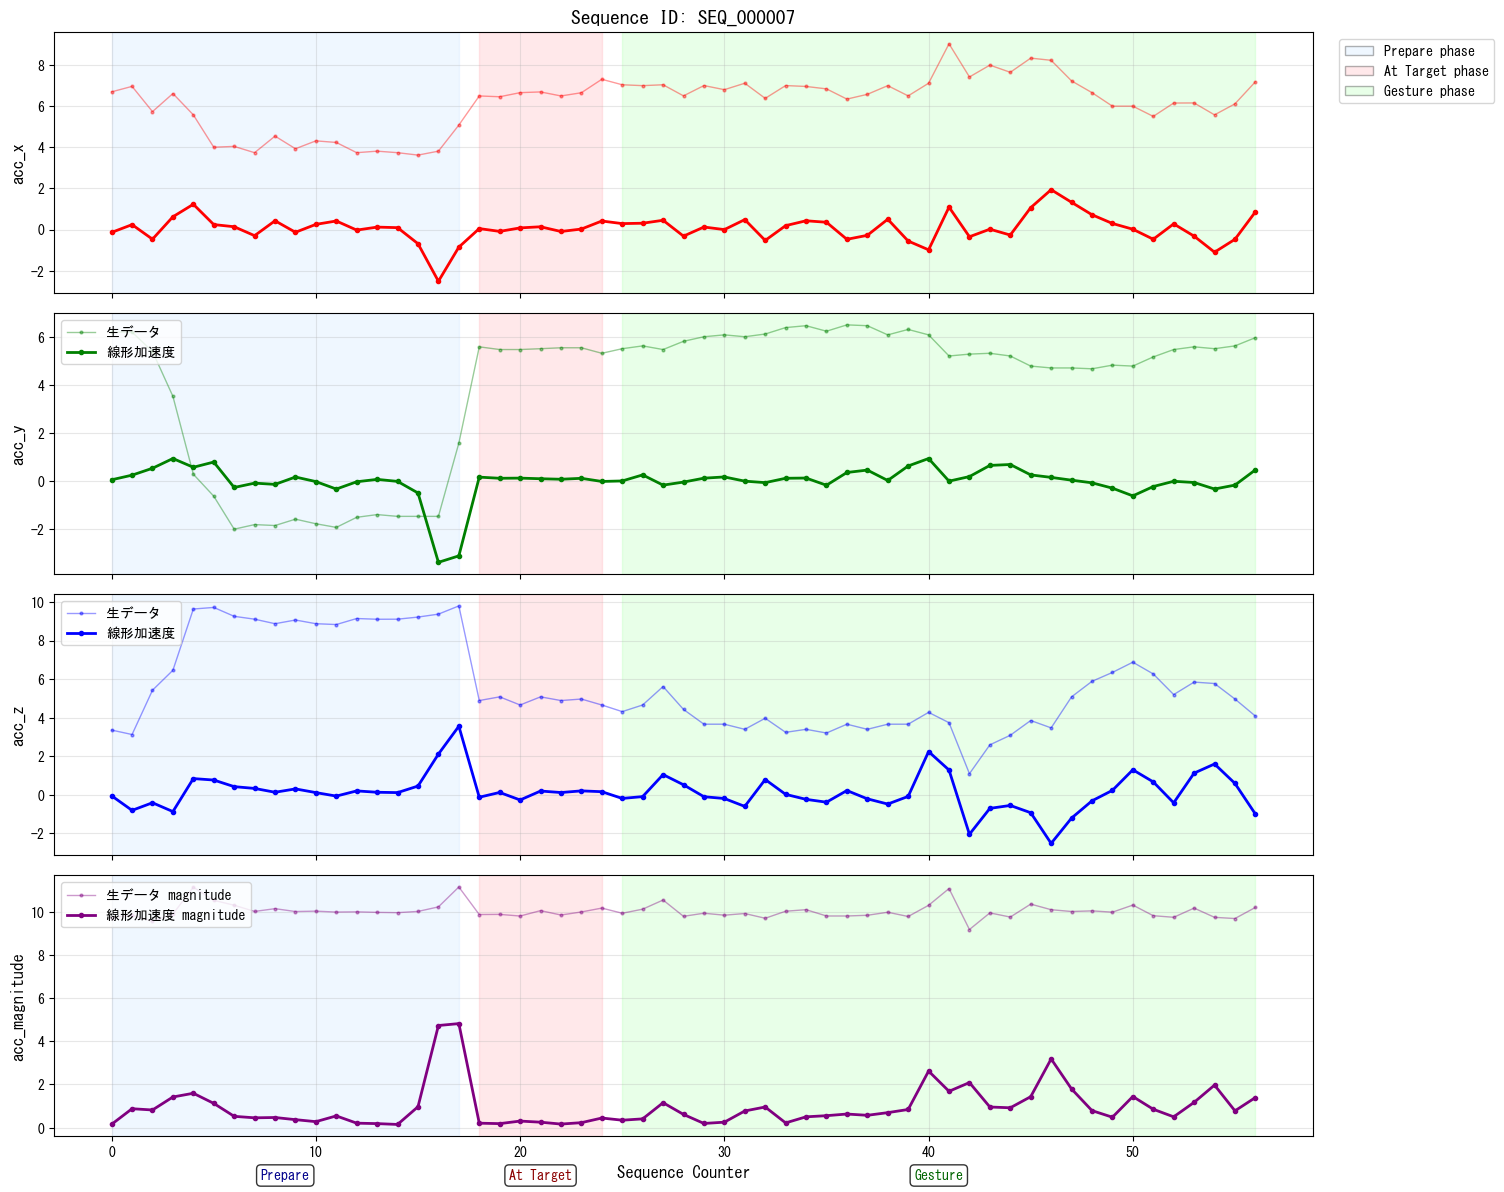

========== 統計情報: ==========
シーケンスID: SEQ_000007
被験者ID: SUBJ_059520
ジェスチャー: Cheek - pinch skin
BFRBタイプ: Target
方向: Seated Lean Non Dom - FACE DOWN
データポイント数: 57
フェーズ変化: Prepare → At Target → Gesture

📈 フェーズ別統計:
  Prepare: 18 データポイント (31.6%)
  At Target: 7 データポイント (12.3%)
  Gesture: 32 データポイント (56.1%)

生データ統計:
  acc_x - 平均: 6.1531, 標準偏差: 1.3342
  acc_y - 平均: 3.9156, 標準偏差: 3.0483
  acc_z - 平均: 5.5778, 標準偏差: 2.3375
  acc_magnitude - 平均: 10.0217, 標準偏差: 0.3439

線形加速度統計:
  linear_acc_x - 平均: 0.0652, 標準偏差: 0.6632
  linear_acc_y - 平均: -0.0165, 標準偏差: 0.7051
  linear_acc_z - 平均: 0.1231, 標準偏差: 0.9537
  linear_magnitude - 平均: 0.9506, 標準偏差: 0.9731


In [22]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

target_gesture = "Cheek - pinch skin"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    plot_acceleration_timeseries_single(train, target_sequences[0])

## Detect moving segment

In [ ]:
def calculate_linear_acc_features(data: pd.DataFrame) -> Dict[str, np.ndarray]:
    """
    線形加速度ベースの動作特徴量計算
    """
    features = {}

    acc_data = data[['acc_x', 'acc_y', 'acc_z']]
    rot_data = data[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
    
    # 線形加速度
    linear_accel = remove_gravity_from_acc(acc_data, rot_data)
    features['linear_acc_x'] = linear_accel[:, 0]
    features['linear_acc_y'] = linear_accel[:, 1]
    features['linear_acc_z'] = linear_accel[:, 2]
    features['linear_acc_magnitude'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
    
    # ベクトル方向
    


    # 線形Jerk（線形加速度の変化率）
    features['linear_jerk_x'] = np.diff(linear_accel[:, 0], prepend=linear_accel[0, 0])
    features['linear_jerk_y'] = np.diff(linear_accel[:, 1], prepend=linear_accel[0, 1])
    features['linear_jerk_z'] = np.diff(linear_accel[:, 2], prepend=linear_accel[0, 2])
    features['linear_jerk_magnitude'] = np.linalg.norm(
        np.diff(linear_accel, axis=0, prepend=linear_accel[0:1]), axis=1
    )
    
    # 線形加速度の変動性
    features['linear_acc_x_variation'] = pd.Series(features['linear_acc_x']).rolling(
        window=5, center=True, min_periods=1
    ).std().fillna(0).values
    
    features['linear_acc_y_variation'] = pd.Series(features['linear_acc_y']).rolling(
        window=5, center=True, min_periods=1
    ).std().fillna(0).values
    
    features['linear_acc_z_variation'] = pd.Series(features['linear_acc_z']).rolling(
        window=5, center=True, min_periods=1
    ).std().fillna(0).values
    
    features['linear_acc_variation'] = pd.Series(features['linear_acc_magnitude']).rolling(
        window=5, center=True, min_periods=1
    ).std().fillna(0).values
    
    # 総線形動作量
    features['total_linear_motion'] = np.sum(np.abs(linear_accel), axis=1)
    
    return features

In [ ]:
def plot_linear_acc_features_timeseries(data, sequence_id, figsize=(15, 16)):
    """
    指定されたsequence_idの線形加速度特徴量を時系列でプロット
    フェーズの変化を背景色で視覚化
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム（元の生データ）
    sequence_id : str
        プロットするsequence_id
    figsize : tuple
        図のサイズ
    """
    
    # 指定されたsequence_idのデータを抽出
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    
    if len(seq_data) == 0:
        print(f"sequence_id '{sequence_id}' のデータが見つかりません")
        return
    
    # sequence_counterでソート
    seq_data = seq_data.sort_values('sequence_counter')
    
    # 線形加速度の特徴量を計算
    if all(col in seq_data.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
        features = calculate_linear_acc_features(seq_data)
        
        # 特徴量をデータフレームに追加
        for feature_name, feature_values in features.items():
            if len(feature_values) == len(seq_data):
                seq_data[feature_name] = feature_values
        
        has_linear = True
    else:
        print("警告: 線形加速度計算に必要な回転データが不足しています")
        return
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    
    # フェーズの変化点を特定
    phase_changes = []
    unique_phases = []
    current_phase = None
    
    for i, (idx, row) in enumerate(seq_data.iterrows()):
        if row['behavior'] != current_phase:
            if current_phase is not None:
                phase_changes.append(i)
            current_phase = row['behavior']
            unique_phases.append(current_phase)
    
    # 最後のポイントを追加
    phase_changes.append(len(seq_data))
    
    # プロット作成（6つのサブプロット）
    fig, axes = plt.subplots(6, 1, figsize=figsize, sharex=True)
    
    # フェーズ別の色設定
    phase_colors = {
        'Prepare': '#CCE5FF',        # 明るい青
        'Moving': '#FFD4A3',         # 明るいオレンジ
        'At Target': '#FFB3BA',      # 明るいピンク
        'Gesture': '#B3FFB3'         # 明るい緑
    }
    
    # 各軸に対してフェーズ背景を描画
    for ax in axes:
        start_idx = 0
        for i, phase in enumerate(unique_phases):
            end_idx = phase_changes[i]
            
            # 背景色を設定
            x_start = seq_data.iloc[start_idx]['sequence_counter']
            x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
            
            # behaviorの値をテキスト表記に変換
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')  # デフォルト色
            ax.axvspan(x_start, x_end, alpha=0.3, color=color, label=f'Phase: {phase_text}' if ax == axes[0] else "")
            
            start_idx = end_idx
    
    # 1. 線形加速度の大きさ (linear_acc_magnitude)
    axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                 color='red', linewidth=2, marker='o', markersize=3, 
                 label='Linear Acceleration Magnitude', zorder=5)
    axes[0].set_ylabel('Linear Acc\nMagnitude', fontsize=12, fontweight='bold')
    axes[0].set_title(f'線形加速度特徴量: Sequence ID {sequence_id}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')
    
    # 2. 線形Jerk（線形加速度の変化率）
    axes[1].plot(seq_data['sequence_counter'], seq_data['linear_jerk_magnitude'], 
                 color='purple', linewidth=2, marker='o', markersize=3, 
                 label='Linear Jerk Magnitude', zorder=5)
    axes[1].set_ylabel('Linear Jerk\nMagnitude', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper left')
    
    # 3. 線形加速度の変動性
    axes[2].plot(seq_data['sequence_counter'], seq_data['linear_acc_variation'], 
                 color='green', linewidth=2, marker='o', markersize=3, 
                 label='Linear Acc Variation', zorder=5)
    axes[2].set_ylabel('Linear Acc\nVariation', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper left')
    
    # 4. 総線形動作量
    axes[3].plot(seq_data['sequence_counter'], seq_data['total_linear_motion'], 
                 color='orange', linewidth=2, marker='o', markersize=3, 
                 label='Total Linear Motion', zorder=5)
    axes[3].set_ylabel('Total Linear\nMotion', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(loc='upper left')
    
    # 5. 線形加速度の各軸成分（3軸まとめて表示）
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_x'], 
                 color='red', linewidth=2, marker='o', markersize=2, alpha=0.7,
                 label='Linear Acc X', zorder=5)
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_y'], 
                 color='green', linewidth=2, marker='s', markersize=2, alpha=0.7,
                 label='Linear Acc Y', zorder=5)
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_z'], 
                 color='blue', linewidth=2, marker='^', markersize=2, alpha=0.7,
                 label='Linear Acc Z', zorder=5)
    axes[4].set_ylabel('Linear Acc\nComponents', fontsize=12, fontweight='bold')
    axes[4].grid(True, alpha=0.3)
    axes[4].legend(loc='upper left')
    
    # 6. 特徴量の複合比較（正規化して比較）
    # 各特徴量を0-1に正規化して比較しやすくする
    mag_norm = (seq_data['linear_acc_magnitude'] - seq_data['linear_acc_magnitude'].min()) / (seq_data['linear_acc_magnitude'].max() - seq_data['linear_acc_magnitude'].min() + 1e-8)
    jerk_norm = (seq_data['linear_jerk_magnitude'] - seq_data['linear_jerk_magnitude'].min()) / (seq_data['linear_jerk_magnitude'].max() - seq_data['linear_jerk_magnitude'].min() + 1e-8)
    var_norm = (seq_data['linear_acc_variation'] - seq_data['linear_acc_variation'].min()) / (seq_data['linear_acc_variation'].max() - seq_data['linear_acc_variation'].min() + 1e-8)
    motion_norm = (seq_data['total_linear_motion'] - seq_data['total_linear_motion'].min()) / (seq_data['total_linear_motion'].max() - seq_data['total_linear_motion'].min() + 1e-8)
    
    axes[5].plot(seq_data['sequence_counter'], mag_norm, 
                 color='red', linewidth=2, alpha=0.8, label='Magnitude (normalized)', zorder=5)
    axes[5].plot(seq_data['sequence_counter'], jerk_norm, 
                 color='purple', linewidth=2, alpha=0.8, label='Jerk (normalized)', zorder=5)
    axes[5].plot(seq_data['sequence_counter'], var_norm, 
                 color='green', linewidth=2, alpha=0.8, label='Variation (normalized)', zorder=5)
    axes[5].plot(seq_data['sequence_counter'], motion_norm, 
                 color='orange', linewidth=2, alpha=0.8, label='Total Motion (normalized)', zorder=5)
    
    axes[5].set_ylabel('Normalized\nFeatures', fontsize=12, fontweight='bold')
    axes[5].set_xlabel('Sequence Counter', fontsize=12, fontweight='bold')
    axes[5].grid(True, alpha=0.3)
    axes[5].legend(loc='upper left')
    axes[5].set_ylim(0, 1.1)
    
    # フェーズ名を最下段のグラフの下部に表示
    start_idx = 0
    for i, phase in enumerate(unique_phases):
        end_idx = phase_changes[i]
        
        # フェーズ名を表示する位置を計算
        x_start = seq_data.iloc[start_idx]['sequence_counter']
        x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
        x_mid = (x_start + x_end) / 2
        
        # 最下段のグラフの下部に配置
        y_min = axes[5].get_ylim()[0]
        y_range = axes[5].get_ylim()[1] - axes[5].get_ylim()[0]
        y_pos = y_min - y_range * 0.15  # グラフの下部から少し離れた位置
        
        # behaviorの値をテキスト表記に変換
        phase_text = behavior_to_text.get(phase, phase)
        
        # フェーズに応じてテキストの色を調整
        text_color_map = {
            'Prepare': 'darkblue',
            'Moving': 'darkorange', 
            'At Target': 'darkred',
            'Gesture': 'darkgreen'
        }
        text_color = text_color_map.get(phase_text, 'black')
        axes[5].text(x_mid, y_pos, phase_text, 
                    ha='center', va='center', fontweight='bold', color=text_color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        start_idx = end_idx
    
    # 凡例を追加（最上段のグラフのみ）
    if len(unique_phases) > 1:
        # カスタム凡例を作成
        legend_elements = []
        for phase in unique_phases:
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.3, 
                                               edgecolor='black', label=f'{phase_text} phase'))
        axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
        
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print(f"========== 線形加速度特徴量統計情報 ==========")
    print(f"シーケンスID: {seq_data['sequence_id'].iloc[0]}")
    print(f"被験者ID: {seq_data['subject'].iloc[0]}")
    print(f"ジェスチャー: {seq_data['gesture'].iloc[0]}")
    print(f"方向: {seq_data['orientation'].iloc[0]}")
    print(f"データポイント数: {len(seq_data)}")

    unique_phases_text = [behavior_to_text.get(phase, phase) for phase in unique_phases]
    print(f"フェーズ変化: {' → '.join(unique_phases_text)}")

    print(f"\n📈 フェーズ別統計:")
    for phase in unique_phases:
        phase_text = behavior_to_text.get(phase, phase)
        phase_data = seq_data[seq_data['behavior'] == phase]
        print(f"  {phase_text}: {len(phase_data)} データポイント ({len(phase_data)/len(seq_data)*100:.1f}%)")
    
    print(f"\n📊 線形加速度特徴量統計:")
    print(f"  Linear Acceleration Magnitude:")
    print(f"    平均: {seq_data['linear_acc_magnitude'].mean():.4f}, 標準偏差: {seq_data['linear_acc_magnitude'].std():.4f}")
    print(f"    最小: {seq_data['linear_acc_magnitude'].min():.4f}, 最大: {seq_data['linear_acc_magnitude'].max():.4f}")
    
    print(f"  Linear Jerk Magnitude:")
    print(f"    平均: {seq_data['linear_jerk_magnitude'].mean():.4f}, 標準偏差: {seq_data['linear_jerk_magnitude'].std():.4f}")
    print(f"    最小: {seq_data['linear_jerk_magnitude'].min():.4f}, 最大: {seq_data['linear_jerk_magnitude'].max():.4f}")
    
    print(f"  Linear Acceleration Variation:")
    print(f"    平均: {seq_data['linear_acc_variation'].mean():.4f}, 標準偏差: {seq_data['linear_acc_variation'].std():.4f}")
    print(f"    最小: {seq_data['linear_acc_variation'].min():.4f}, 最大: {seq_data['linear_acc_variation'].max():.4f}")
    
    print(f"  Total Linear Motion:")
    print(f"    平均: {seq_data['total_linear_motion'].mean():.4f}, 標準偏差: {seq_data['total_linear_motion'].std():.4f}")
    print(f"    最小: {seq_data['total_linear_motion'].min():.4f}, 最大: {seq_data['total_linear_motion'].max():.4f}")
    
    print(f"\n  Linear Acceleration Components:")
    print(f"    linear_acc_x - 平均: {seq_data['linear_acc_x'].mean():.4f}, 標準偏差: {seq_data['linear_acc_x'].std():.4f}")
    print(f"    linear_acc_y - 平均: {seq_data['linear_acc_y'].mean():.4f}, 標準偏差: {seq_data['linear_acc_y'].std():.4f}")
    print(f"    linear_acc_z - 平均: {seq_data['linear_acc_z'].mean():.4f}, 標準偏差: {seq_data['linear_acc_z'].std():.4f}")

    # フェーズ別の特徴量分析
    print(f"\n📈 フェーズ別特徴量分析:")
    for phase in unique_phases:
        phase_text = behavior_to_text.get(phase, phase)
        phase_data = seq_data[seq_data['behavior'] == phase]
        
        print(f"\n  🔹 {phase_text} フェーズ:")
        print(f"    Linear Acc Magnitude: {phase_data['linear_acc_magnitude'].mean():.4f} ± {phase_data['linear_acc_magnitude'].std():.4f}")
        print(f"    Linear Jerk Magnitude: {phase_data['linear_jerk_magnitude'].mean():.4f} ± {phase_data['linear_jerk_magnitude'].std():.4f}")
        print(f"    Linear Acc Variation: {phase_data['linear_acc_variation'].mean():.4f} ± {phase_data['linear_acc_variation'].std():.4f}")
        print(f"    Total Linear Motion: {phase_data['total_linear_motion'].mean():.4f} ± {phase_data['total_linear_motion'].std():.4f}")

In [41]:
def plot_linear_acc_features_timeseries_xyz(data, sequence_id, figsize=(15, 20)):
    """
    指定されたsequence_idの線形加速度特徴量をX,Y,Z軸ごとに時系列でプロット
    フェーズの変化を背景色で視覚化
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム（元の生データ）
    sequence_id : str
        プロットするsequence_id
    figsize : tuple
        図のサイズ
    """
    
    # 指定されたsequence_idのデータを抽出
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    
    if len(seq_data) == 0:
        print(f"sequence_id '{sequence_id}' のデータが見つかりません")
        return
    
    # sequence_counterでソート
    seq_data = seq_data.sort_values('sequence_counter')
    
    # 線形加速度の特徴量を計算
    if all(col in seq_data.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
        features = calculate_linear_acc_features(seq_data)
        
        # 特徴量をデータフレームに追加
        for feature_name, feature_values in features.items():
            if len(feature_values) == len(seq_data):
                seq_data[feature_name] = feature_values
        
        has_linear = True
    else:
        print("警告: 線形加速度計算に必要な回転データが不足しています")
        return
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    
    # フェーズの変化点を特定
    phase_changes = []
    unique_phases = []
    current_phase = None
    
    for i, (idx, row) in enumerate(seq_data.iterrows()):
        if row['behavior'] != current_phase:
            if current_phase is not None:
                phase_changes.append(i)
            current_phase = row['behavior']
            unique_phases.append(current_phase)
    
    # 最後のポイントを追加
    phase_changes.append(len(seq_data))
    
    # プロット作成（7つのサブプロット）
    fig, axes = plt.subplots(7, 1, figsize=figsize, sharex=True)
    
    # フェーズ別の色設定
    phase_colors = {
        'Prepare': '#CCE5FF',        # 明るい青
        'Moving': '#FFD4A3',         # 明るいオレンジ
        'At Target': '#FFB3BA',      # 明るいピンク
        'Gesture': '#B3FFB3'         # 明るい緑
    }
    
    # 軸ごとの色設定
    axis_colors = {
        'x': 'red',
        'y': 'green', 
        'z': 'blue'
    }
    
    # 各軸に対してフェーズ背景を描画
    for ax in axes:
        start_idx = 0
        for i, phase in enumerate(unique_phases):
            end_idx = phase_changes[i]
            
            # 背景色を設定
            x_start = seq_data.iloc[start_idx]['sequence_counter']
            x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
            
            # behaviorの値をテキスト表記に変換
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')  # デフォルト色
            ax.axvspan(x_start, x_end, alpha=0.3, color=color, label=f'Phase: {phase_text}' if ax == axes[0] else "")
            
            start_idx = end_idx
    
    # 1. 線形加速度 X,Y,Z軸
    axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_x'], 
                 color=axis_colors['x'], linewidth=2, marker='o', markersize=2, 
                 label='Linear Acc X', zorder=5)
    axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_y'], 
                 color=axis_colors['y'], linewidth=2, marker='s', markersize=2, 
                 label='Linear Acc Y', zorder=5)
    axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_z'], 
                 color=axis_colors['z'], linewidth=2, marker='^', markersize=2, 
                 label='Linear Acc Z', zorder=5)
    axes[0].set_ylabel('Linear Acc\n(X,Y,Z)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'線形加速度特徴量 (軸別): Sequence ID {sequence_id}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')
    
    # 2. 線形Jerk X軸
    axes[1].plot(seq_data['sequence_counter'], seq_data['linear_jerk_x'], 
                 color=axis_colors['x'], linewidth=2, marker='o', markersize=2, 
                 label='Linear Jerk X', zorder=5)
    axes[1].set_ylabel('Linear Jerk X', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper left')
    
    # 3. 線形Jerk Y軸
    axes[2].plot(seq_data['sequence_counter'], seq_data['linear_jerk_y'], 
                 color=axis_colors['y'], linewidth=2, marker='s', markersize=2, 
                 label='Linear Jerk Y', zorder=5)
    axes[2].set_ylabel('Linear Jerk Y', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='upper left')
    
    # 4. 線形Jerk Z軸
    axes[3].plot(seq_data['sequence_counter'], seq_data['linear_jerk_z'], 
                 color=axis_colors['z'], linewidth=2, marker='^', markersize=2, 
                 label='Linear Jerk Z', zorder=5)
    axes[3].set_ylabel('Linear Jerk Z', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend(loc='upper left')
    
    # 5. 線形加速度Variation X,Y,Z軸
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_x_variation'], 
                 color=axis_colors['x'], linewidth=2, marker='o', markersize=2, alpha=0.8,
                 label='Linear Acc Variation X', zorder=5)
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_y_variation'], 
                 color=axis_colors['y'], linewidth=2, marker='s', markersize=2, alpha=0.8,
                 label='Linear Acc Variation Y', zorder=5)
    axes[4].plot(seq_data['sequence_counter'], seq_data['linear_acc_z_variation'], 
                 color=axis_colors['z'], linewidth=2, marker='^', markersize=2, alpha=0.8,
                 label='Linear Acc Variation Z', zorder=5)
    axes[4].set_ylabel('Linear Acc\nVariation (X,Y,Z)', fontsize=12, fontweight='bold')
    axes[4].grid(True, alpha=0.3)
    axes[4].legend(loc='upper left')
    
    # 6. 統合された特徴量（magnitude系）
    axes[5].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                 color='purple', linewidth=2, marker='o', markersize=2, alpha=0.8,
                 label='Linear Acc Magnitude', zorder=5)
    axes[5].plot(seq_data['sequence_counter'], seq_data['linear_jerk_magnitude'], 
                 color='orange', linewidth=2, marker='s', markersize=2, alpha=0.8,
                 label='Linear Jerk Magnitude', zorder=5)
    axes[5].plot(seq_data['sequence_counter'], seq_data['total_linear_motion'], 
                 color='brown', linewidth=2, marker='^', markersize=2, alpha=0.8,
                 label='Total Linear Motion', zorder=5)
    axes[5].set_ylabel('Magnitude\nFeatures', fontsize=12, fontweight='bold')
    axes[5].grid(True, alpha=0.3)
    axes[5].legend(loc='upper left')
    
    # 7. Jerkの方向別分析（正規化）
    # 各軸のJerkを正規化して方向的な特徴を比較
    jerk_x_abs = np.abs(seq_data['linear_jerk_x'])
    jerk_y_abs = np.abs(seq_data['linear_jerk_y'])
    jerk_z_abs = np.abs(seq_data['linear_jerk_z'])
    total_jerk = jerk_x_abs + jerk_y_abs + jerk_z_abs + 1e-8  # ゼロ除算を防ぐ
    
    jerk_x_ratio = jerk_x_abs / total_jerk
    jerk_y_ratio = jerk_y_abs / total_jerk
    jerk_z_ratio = jerk_z_abs / total_jerk
    
    axes[6].plot(seq_data['sequence_counter'], jerk_x_ratio, 
                 color=axis_colors['x'], linewidth=2, alpha=0.8, label='Jerk X Ratio', zorder=5)
    axes[6].plot(seq_data['sequence_counter'], jerk_y_ratio, 
                 color=axis_colors['y'], linewidth=2, alpha=0.8, label='Jerk Y Ratio', zorder=5)
    axes[6].plot(seq_data['sequence_counter'], jerk_z_ratio, 
                 color=axis_colors['z'], linewidth=2, alpha=0.8, label='Jerk Z Ratio', zorder=5)
    
    axes[6].set_ylabel('Jerk Direction\nRatio', fontsize=12, fontweight='bold')
    axes[6].set_xlabel('Sequence Counter', fontsize=12, fontweight='bold')
    axes[6].grid(True, alpha=0.3)
    axes[6].legend(loc='upper left')
    axes[6].set_ylim(0, 1.1)
    
    # フェーズ名を最下段のグラフの下部に表示
    start_idx = 0
    for i, phase in enumerate(unique_phases):
        end_idx = phase_changes[i]
        
        # フェーズ名を表示する位置を計算
        x_start = seq_data.iloc[start_idx]['sequence_counter']
        x_end = seq_data.iloc[end_idx-1]['sequence_counter'] if end_idx > 0 else x_start
        x_mid = (x_start + x_end) / 2
        
        # 最下段のグラフの下部に配置
        y_min = axes[6].get_ylim()[0]
        y_range = axes[6].get_ylim()[1] - axes[6].get_ylim()[0]
        y_pos = y_min - y_range * 0.15  # グラフの下部から少し離れた位置
        
        # behaviorの値をテキスト表記に変換
        phase_text = behavior_to_text.get(phase, phase)
        
        # フェーズに応じてテキストの色を調整
        text_color_map = {
            'Prepare': 'darkblue',
            'Moving': 'darkorange', 
            'At Target': 'darkred',
            'Gesture': 'darkgreen'
        }
        text_color = text_color_map.get(phase_text, 'black')
        axes[6].text(x_mid, y_pos, phase_text, 
                    ha='center', va='center', fontweight='bold', color=text_color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        start_idx = end_idx
    
    # 凡例を追加（最上段のグラフのみ）
    if len(unique_phases) > 1:
        # カスタム凡例を作成
        legend_elements = []
        for phase in unique_phases:
            phase_text = behavior_to_text.get(phase, phase)
            color = phase_colors.get(phase_text, '#F0F0F0')
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.3, 
                                               edgecolor='black', label=f'{phase_text} phase'))
        axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
        
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print(f"========== 線形加速度特徴量統計情報 (軸別) ==========")
    print(f"シーケンスID: {seq_data['sequence_id'].iloc[0]}")
    print(f"被験者ID: {seq_data['subject'].iloc[0]}")
    print(f"ジェスチャー: {seq_data['gesture'].iloc[0]}")
    print(f"方向: {seq_data['orientation'].iloc[0]}")
    print(f"データポイント数: {len(seq_data)}")

    unique_phases_text = [behavior_to_text.get(phase, phase) for phase in unique_phases]
    print(f"フェーズ変化: {' → '.join(unique_phases_text)}")

    # 軸別のJerk統計
    print(f"\n📊 軸別Linear Jerk統計:")
    for axis in ['x', 'y', 'z']:
        jerk_col = f'linear_jerk_{axis}'
        print(f"  Linear Jerk {axis.upper()}:")
        print(f"    平均: {seq_data[jerk_col].mean():.4f}, 標準偏差: {seq_data[jerk_col].std():.4f}")
        print(f"    最小: {seq_data[jerk_col].min():.4f}, 最大: {seq_data[jerk_col].max():.4f}")
        print(f"    絶対値平均: {np.abs(seq_data[jerk_col]).mean():.4f}")
    
    # 軸別のVariation統計
    print(f"\n📊 軸別Linear Acceleration Variation統計:")
    for axis in ['x', 'y', 'z']:
        var_col = f'linear_acc_{axis}_variation'
        print(f"  Linear Acc Variation {axis.upper()}:")
        print(f"    平均: {seq_data[var_col].mean():.4f}, 標準偏差: {seq_data[var_col].std():.4f}")
        print(f"    最小: {seq_data[var_col].min():.4f}, 最大: {seq_data[var_col].max():.4f}")
    
    # 方向性分析
    print(f"\n📈 動作方向性分析:")
    total_jerk_abs = np.abs(seq_data['linear_jerk_x']).sum() + np.abs(seq_data['linear_jerk_y']).sum() + np.abs(seq_data['linear_jerk_z']).sum()
    if total_jerk_abs > 0:
        jerk_x_dominance = np.abs(seq_data['linear_jerk_x']).sum() / total_jerk_abs
        jerk_y_dominance = np.abs(seq_data['linear_jerk_y']).sum() / total_jerk_abs
        jerk_z_dominance = np.abs(seq_data['linear_jerk_z']).sum() / total_jerk_abs
        
        print(f"  Jerk優勢度:")
        print(f"    X軸 (左右): {jerk_x_dominance:.3f} ({jerk_x_dominance*100:.1f}%)")
        print(f"    Y軸 (前後): {jerk_y_dominance:.3f} ({jerk_y_dominance*100:.1f}%)")
        print(f"    Z軸 (上下): {jerk_z_dominance:.3f} ({jerk_z_dominance*100:.1f}%)")
        
        # 優勢軸の判定
        dominances = {'X軸 (左右)': jerk_x_dominance, 'Y軸 (前後)': jerk_y_dominance, 'Z軸 (上下)': jerk_z_dominance}
        dominant_axis = max(dominances, key=dominances.get)
        print(f"    主要動作方向: {dominant_axis}")

    # フェーズ別の方向性分析
    print(f"\n📈 フェーズ別方向性分析:")
    for phase in unique_phases:
        phase_text = behavior_to_text.get(phase, phase)
        phase_data = seq_data[seq_data['behavior'] == phase]
        
        print(f"\n  🔹 {phase_text} フェーズ:")
        
        # 各軸のJerk平均
        jerk_x_mean = np.abs(phase_data['linear_jerk_x']).mean()
        jerk_y_mean = np.abs(phase_data['linear_jerk_y']).mean()
        jerk_z_mean = np.abs(phase_data['linear_jerk_z']).mean()
        
        print(f"    平均Jerk絶対値: X={jerk_x_mean:.4f}, Y={jerk_y_mean:.4f}, Z={jerk_z_mean:.4f}")
        
        # このフェーズでの優勢軸
        phase_jerk_total = jerk_x_mean + jerk_y_mean + jerk_z_mean
        if phase_jerk_total > 0:
            phase_dominances = {
                'X軸 (左右)': jerk_x_mean / phase_jerk_total,
                'Y軸 (前後)': jerk_y_mean / phase_jerk_total,
                'Z軸 (上下)': jerk_z_mean / phase_jerk_total
            }
            phase_dominant_axis = max(phase_dominances, key=phase_dominances.get)
            print(f"    主要動作方向: {phase_dominant_axis} ({phase_dominances[phase_dominant_axis]*100:.1f}%)")

In [75]:
def extract_periodicity_features_fft(data, sequence_id, figsize=(15, 12)):
    """
    FFTを使った周期性特徴量抽出
    """
    
    # データ準備
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    seq_data = seq_data.sort_values('sequence_counter')

    # Gestureだけにフィルター
    seq_data = seq_data[seq_data['behavior'] == 'Performs gesture']
    
    features = calculate_linear_acc_features(seq_data)
    for feature_name, feature_values in features.items():
        if len(feature_values) == len(seq_data):
            seq_data[feature_name] = feature_values
    
    # サンプリング周波数
    sampling_rate = 10  # Hz
    
    # 各軸と統合特徴量での周期性解析
    signals = {
        'X軸': seq_data['linear_acc_x'].values,
        'Y軸': seq_data['linear_acc_y'].values, 
        'Z軸': seq_data['linear_acc_z'].values,
        'Magnitude': seq_data['linear_acc_magnitude'].values
    }
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    periodicity_results = {}
    
    for i, (signal_name, signal) in enumerate(signals.items()):
        # FFT計算
        fft_vals = np.fft.fft(signal)
        fft_freq = np.fft.fftfreq(len(signal), 1/sampling_rate)
        fft_magnitude = np.abs(fft_vals)
        
        # 正の周波数のみ取得
        positive_freq_mask = fft_freq > 0
        frequencies = fft_freq[positive_freq_mask]
        magnitudes = fft_magnitude[positive_freq_mask]
        
        # 優勢周波数の検出
        peak_indices = find_peaks(magnitudes, height=np.max(magnitudes)*0.1)[0]
        dominant_frequencies = frequencies[peak_indices]
        dominant_magnitudes = magnitudes[peak_indices]
        
        # 結果を保存
        periodicity_results[signal_name] = {
            'frequencies': frequencies,
            'magnitudes': magnitudes,
            'dominant_freq': frequencies[np.argmax(magnitudes)] if len(frequencies) > 0 else 0,
            'dominant_magnitude': np.max(magnitudes),
            'peak_frequencies': dominant_frequencies,
            'peak_magnitudes': dominant_magnitudes
        }
        
        # プロット
        axes[i].plot(frequencies, magnitudes, 'b-', linewidth=1)
        axes[i].scatter(dominant_frequencies, dominant_magnitudes, 
                       color='red', s=50, zorder=5, label='ピーク')
        axes[i].set_xlabel('周波数 (Hz)')
        axes[i].set_ylabel('振幅')
        axes[i].set_title(f'{signal_name} - 周波数スペクトル')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        axes[i].set_xlim(0, min(50, np.max(frequencies)))  # 0-50Hzに制限
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報
    print(f"========== FFT周期性解析結果 ==========")
    for signal_name, result in periodicity_results.items():
        dominant_freq = result['dominant_freq']
        period = 1/dominant_freq if dominant_freq > 0 else float('inf')
        
        print(f"\n📊 {signal_name}:")
        print(f"  優勢周波数: {dominant_freq:.2f} Hz")
        print(f"  対応周期: {period:.2f} 秒")
        print(f"  振幅: {result['dominant_magnitude']:.2f}")
        print(f"  検出されたピーク数: {len(result['peak_frequencies'])}")
    
    return periodicity_results

def extract_periodicity_features_peaks(data, sequence_id, figsize=(15, 8)):
    """
    ピーク間隔を使った周期性特徴量抽出
    """
    
    # データ準備
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    seq_data = seq_data.sort_values('sequence_counter')
    
    features = calculate_linear_acc_features(seq_data)
    for feature_name, feature_values in features.items():
        if len(feature_values) == len(seq_data):
            seq_data[feature_name] = feature_values
    
    signals = {
        'X軸': seq_data['linear_acc_x'].values,
        'Y軸': seq_data['linear_acc_y'].values, 
        'Z軸': seq_data['linear_acc_z'].values,
        'Magnitude': seq_data['linear_acc_magnitude'].values
    }
    
    fig, axes = plt.subplots(1, len(signals), figsize=figsize)
    
    peak_results = {}
    
    for i, (signal_name, signal) in enumerate(signals.items()):
        # ピーク検出（正と負の両方）
        positive_peaks, _ = find_peaks(signal, distance=5, prominence=np.std(signal)*0.5)
        negative_peaks, _ = find_peaks(-signal, distance=5, prominence=np.std(signal)*0.5)
        
        all_peaks = np.sort(np.concatenate([positive_peaks, negative_peaks]))
        
        # ピーク間隔の計算
        if len(all_peaks) > 1:
            peak_intervals = np.diff(all_peaks)
            mean_interval = np.mean(peak_intervals)
            std_interval = np.std(peak_intervals)
            regularity = 1 / (1 + std_interval / mean_interval) if mean_interval > 0 else 0
        else:
            peak_intervals = np.array([])
            mean_interval = 0
            std_interval = 0
            regularity = 0
        
        peak_results[signal_name] = {
            'positive_peaks': positive_peaks,
            'negative_peaks': negative_peaks,
            'all_peaks': all_peaks,
            'intervals': peak_intervals,
            'mean_interval': mean_interval,
            'std_interval': std_interval,
            'regularity': regularity,
            'peak_count': len(all_peaks)
        }
        
        # プロット
        axes[i].plot(signal, 'b-', linewidth=1, alpha=0.7)
        axes[i].scatter(positive_peaks, signal[positive_peaks], 
                       color='red', s=50, zorder=5, label='正ピーク')
        axes[i].scatter(negative_peaks, signal[negative_peaks], 
                       color='green', s=50, zorder=5, label='負ピーク')
        axes[i].set_xlabel('サンプル')
        axes[i].set_ylabel('加速度')
        axes[i].set_title(f'{signal_name}\nピーク検出')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報
    print(f"========== ピーク間隔周期性解析結果 ==========")
    for signal_name, result in peak_results.items():
        print(f"\n📊 {signal_name}:")
        print(f"  検出ピーク数: {result['peak_count']}")
        print(f"  平均ピーク間隔: {result['mean_interval']:.2f} サンプル")
        print(f"  間隔標準偏差: {result['std_interval']:.2f}")
        print(f"  規則性スコア: {result['regularity']:.3f} (1.0が最も規則的)")
    
    return peak_results


In [33]:
def detect_motion_segments_advanced(data, sequence_id, 
                                   magnitude_threshold=0.5,
                                   jerk_threshold=1.0,
                                   window_size=5,
                                   min_duration=3):
    """
    高度な動作セグメント検出
    
    Parameters:
    -----------
    magnitude_threshold : float
        線形加速度magnitudeの閾値
    jerk_threshold : float
        jerkの閾値
    window_size : int
        移動平均の窓サイズ
    min_duration : int
        最小動作持続時間（データポイント数）
    """
    
    # データ準備
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    seq_data = seq_data.sort_values('sequence_counter')
    
    # 線形加速度計算
    if all(col in seq_data.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
        acc_data = seq_data[['acc_x', 'acc_y', 'acc_z']]
        rot_data = seq_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        linear_accel = remove_gravity_from_acc(acc_data, rot_data)
        
        seq_data['linear_acc_x'] = linear_accel[:, 0]
        seq_data['linear_acc_y'] = linear_accel[:, 1]
        seq_data['linear_acc_z'] = linear_accel[:, 2]
        seq_data['linear_acc_magnitude'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
        
        features = calculate_linear_acc_features(seq_data)

        # 特徴量をデータフレームに追加
        for feature_name, feature_values in features.items():
            if len(feature_values) == len(seq_data):
                seq_data[feature_name] = feature_values
    
    # 1. 移動平均による平滑化
    seq_data['magnitude_smooth'] = seq_data['linear_acc_magnitude'].rolling(
        window=window_size, center=True, min_periods=1
    ).mean()
    
    seq_data['jerk_smooth'] = seq_data['linear_jerk_magnitude'].rolling(
        window=window_size, center=True, min_periods=1
    ).mean()
    
    # 2. 複合的な動作判定
    magnitude_condition = seq_data['magnitude_smooth'] > magnitude_threshold
    jerk_condition = seq_data['jerk_smooth'] > jerk_threshold
    variation_condition = seq_data['linear_acc_variation'] > 0.1
    
    # 複数条件のOR結合（より敏感な検出）
    motion_detected = magnitude_condition | jerk_condition | variation_condition
    
    # 3. 短時間の動作を除去（持続時間フィルタリング）
    motion_segments = []
    in_motion = False
    start_idx = 0
    
    for i, is_motion in enumerate(motion_detected):
        if is_motion and not in_motion:
            # 動作開始
            start_idx = i
            in_motion = True
        elif not is_motion and in_motion:
            # 動作終了
            if i - start_idx >= min_duration:  # 最小持続時間チェック
                motion_segments.append((start_idx, i-1))
            in_motion = False
    
    # 最後のセグメントをチェック
    if in_motion and len(motion_detected) - start_idx >= min_duration:
        motion_segments.append((start_idx, len(motion_detected)-1))
    
    # 4. 結果をデータフレームに追加
    seq_data['motion_detected'] = motion_detected
    seq_data['is_motion_segment'] = False
    
    for start, end in motion_segments:
        seq_data.iloc[start:end+1, seq_data.columns.get_loc('is_motion_segment')] = True
    
    return seq_data, motion_segments

def plot_motion_detection_analysis(data, sequence_id, figsize=(15, 12)):
    """
    動作検出結果の可視化
    """
    
    # 動作検出を実行
    seq_data, motion_segments = detect_motion_segments_advanced(data, sequence_id)
    
    # プロット作成
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    
    # 1. 線形加速度magnitude（生データと平滑化）
    axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                 color='gray', alpha=0.5, linewidth=1, label='生データ')
    axes[0].plot(seq_data['sequence_counter'], seq_data['magnitude_smooth'], 
                 color='red', linewidth=2, label='平滑化')
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='閾値')
    axes[0].set_ylabel('Linear Acc\nMagnitude', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Jerk magnitude
    axes[1].plot(seq_data['sequence_counter'], seq_data['linear_jerk_magnitude'], 
                 color='gray', alpha=0.5, linewidth=1, label='生データ')
    axes[1].plot(seq_data['sequence_counter'], seq_data['jerk_smooth'], 
                 color='purple', linewidth=2, label='平滑化')
    axes[1].axhline(y=1.0, color='purple', linestyle='--', alpha=0.7, label='閾値')
    axes[1].set_ylabel('Linear Jerk\nMagnitude', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. 変動性
    axes[2].plot(seq_data['sequence_counter'], seq_data['linear_acc_variation'], 
                 color='green', linewidth=2, label='Variation')
    axes[2].axhline(y=0.1, color='green', linestyle='--', alpha=0.7, label='閾値')
    axes[2].set_ylabel('Linear Acc\nVariation', fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # 4. 動作検出結果
    axes[3].plot(seq_data['sequence_counter'], seq_data['motion_detected'].astype(int), 
                 color='orange', linewidth=2, label='動作検出（瞬間）', alpha=0.7)
    axes[3].plot(seq_data['sequence_counter'], seq_data['is_motion_segment'].astype(int), 
                 color='blue', linewidth=3, label='動作セグメント（フィルタ後）')
    
    # 動作セグメントを背景でハイライト
    for start, end in motion_segments:
        x_start = seq_data.iloc[start]['sequence_counter']
        x_end = seq_data.iloc[end]['sequence_counter']
        for ax in axes:
            ax.axvspan(x_start, x_end, alpha=0.2, color='blue')
    
    axes[3].set_ylabel('Motion\nDetection', fontweight='bold')
    axes[3].set_xlabel('Sequence Counter', fontweight='bold')
    axes[3].set_ylim(-0.1, 1.1)
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle(f'高度な動作検出分析: Sequence {sequence_id}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 統計情報
    print(f"========== 動作検出結果 ==========")
    print(f"検出された動作セグメント数: {len(motion_segments)}")
    print(f"総データポイント数: {len(seq_data)}")
    
    total_motion_points = sum(end - start + 1 for start, end in motion_segments)
    motion_ratio = total_motion_points / len(seq_data) * 100
    print(f"動作データポイント数: {total_motion_points} ({motion_ratio:.1f}%)")
    
    print(f"\n動作セグメント詳細:")
    for i, (start, end) in enumerate(motion_segments):
        duration = end - start + 1
        start_counter = seq_data.iloc[start]['sequence_counter']
        end_counter = seq_data.iloc[end]['sequence_counter']
        print(f"  セグメント {i+1}: {start_counter}-{end_counter} ({duration} ポイント)")
    
    return seq_data, motion_segments

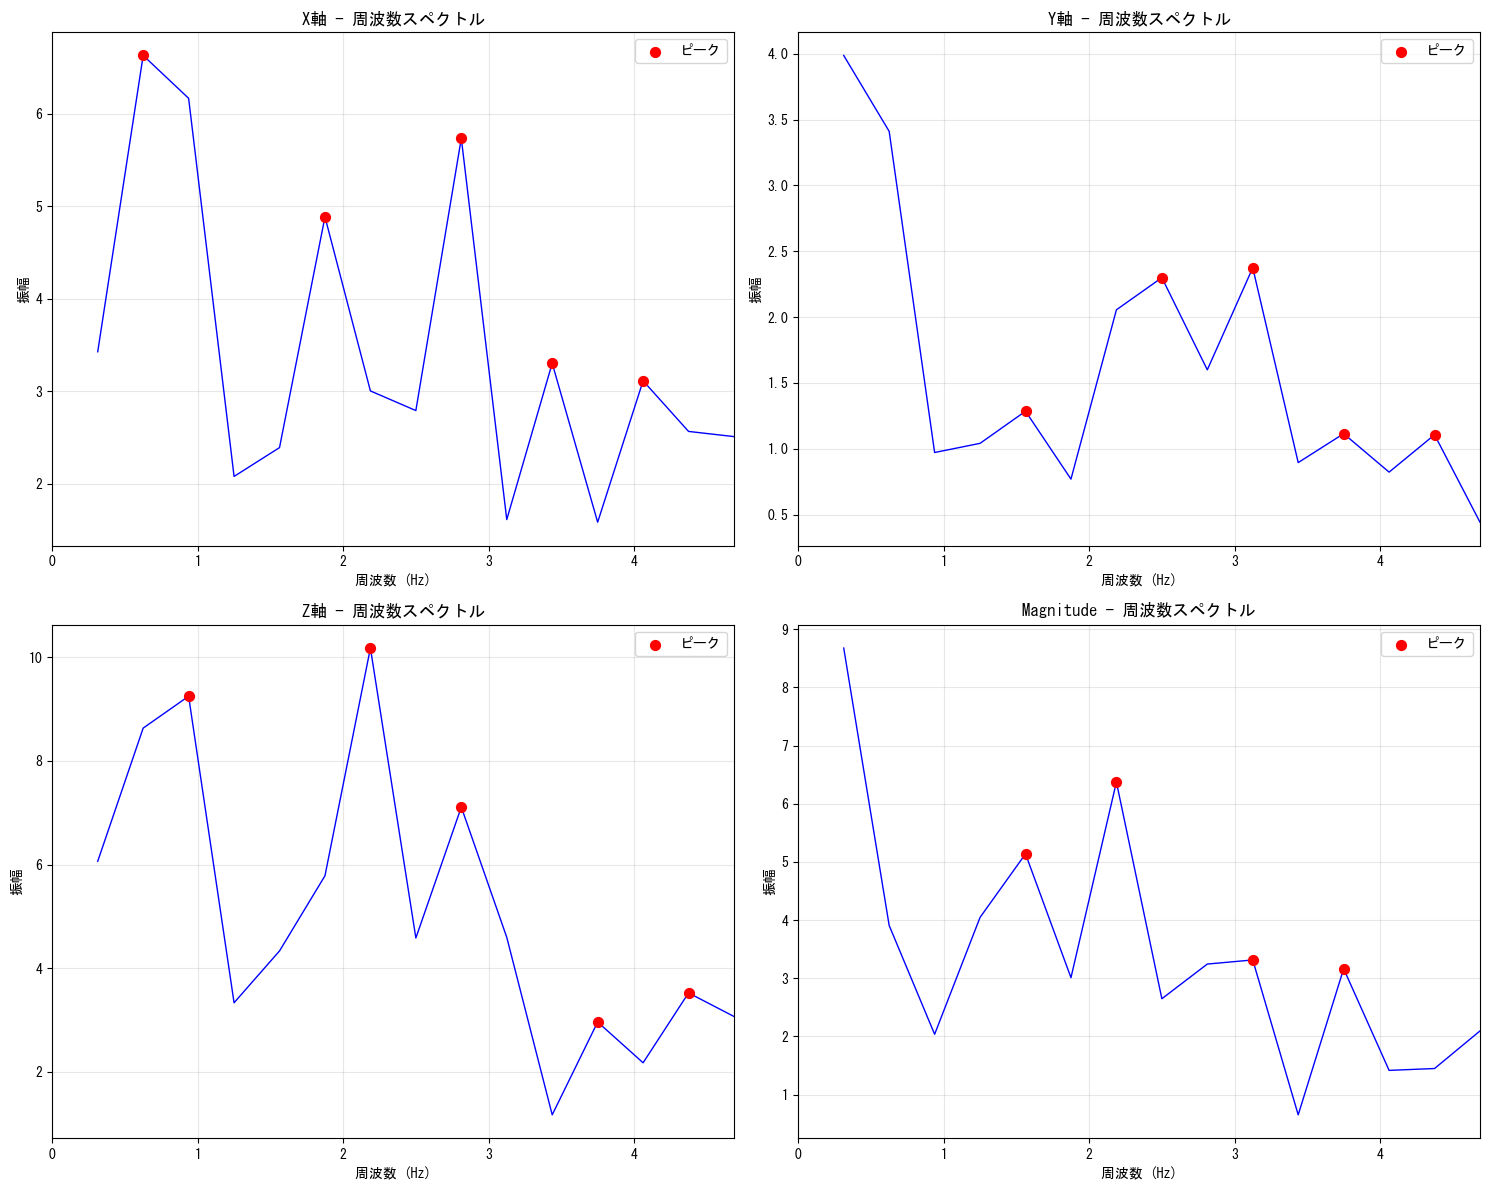

========== FFT周期性解析結果 ==========

📊 X軸:
  優勢周波数: 0.62 Hz
  対応周期: 1.60 秒
  振幅: 6.63
  検出されたピーク数: 5

📊 Y軸:
  優勢周波数: 0.31 Hz
  対応周期: 3.20 秒
  振幅: 3.99
  検出されたピーク数: 5

📊 Z軸:
  優勢周波数: 2.19 Hz
  対応周期: 0.46 秒
  振幅: 10.18
  検出されたピーク数: 5

📊 Magnitude:
  優勢周波数: 0.31 Hz
  対応周期: 3.20 秒
  振幅: 8.67
  検出されたピーク数: 4


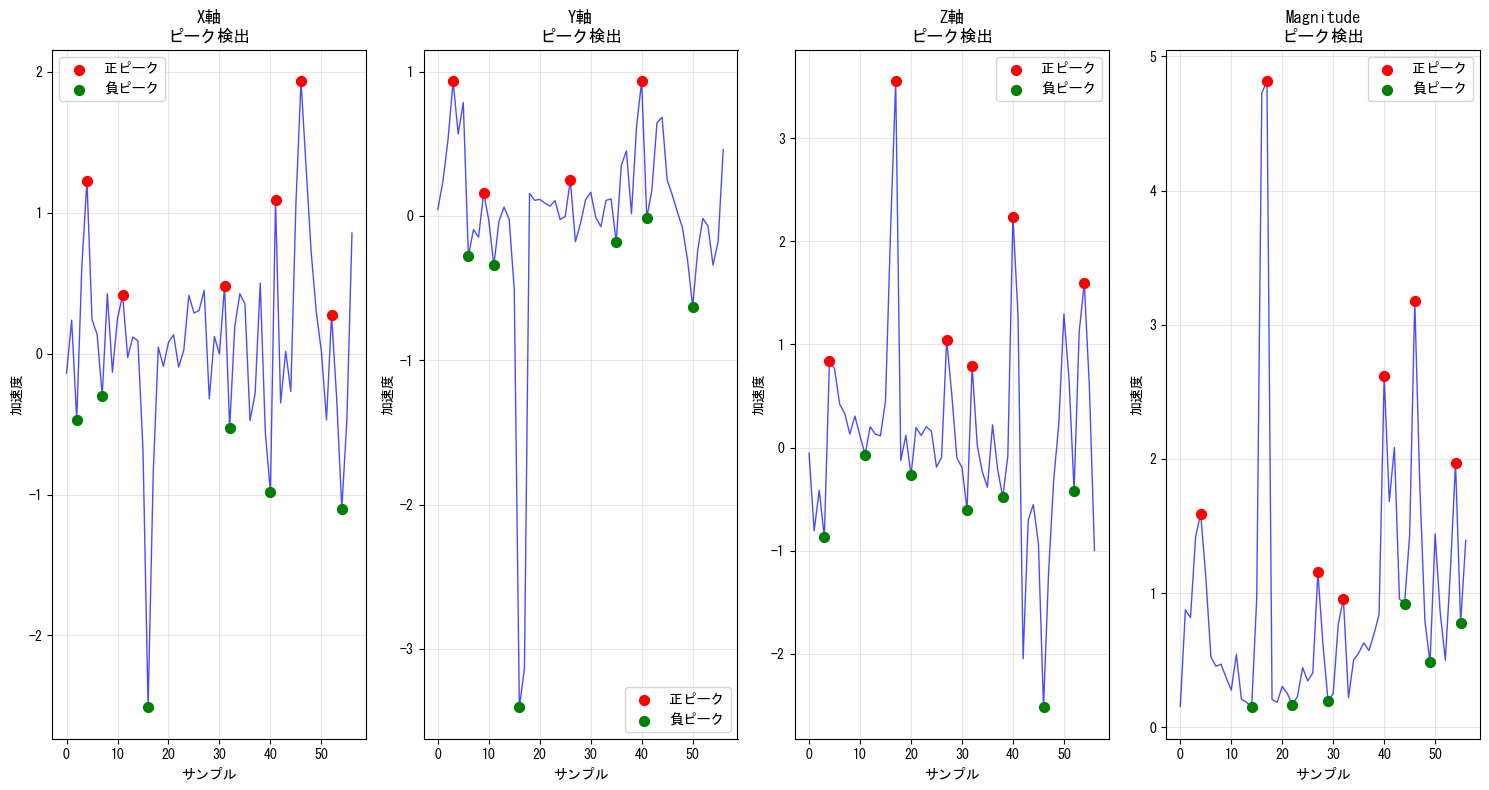

========== ピーク間隔周期性解析結果 ==========

📊 X軸:
  検出ピーク数: 12
  平均ピーク間隔: 4.73 サンプル
  間隔標準偏差: 3.86
  規則性スコア: 0.550 (1.0が最も規則的)

📊 Y軸:
  検出ピーク数: 10
  平均ピーク間隔: 5.22 サンプル
  間隔標準偏差: 3.15
  規則性スコア: 0.623 (1.0が最も規則的)

📊 Z軸:
  検出ピーク数: 13
  平均ピーク間隔: 4.25 サンプル
  間隔標準偏差: 2.24
  規則性スコア: 0.655 (1.0が最も規則的)

📊 Magnitude:
  検出ピーク数: 13
  平均ピーク間隔: 4.25 サンプル
  間隔標準偏差: 2.49
  規則性スコア: 0.631 (1.0が最も規則的)


In [76]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

target_gesture = "Cheek - pinch skin"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    extract_periodicity_features_fft(train, target_sequences[0])
    extract_periodicity_features_peaks(train, target_sequences[0])

In [99]:
def analyze_frequency_time_occupancy(data, sequence_id, 
                                   window_size=30, overlap_ratio=0.8, 
                                   frequency_bands=None, sampling_rate=10):
    """
    特定周波数帯域の時間占有率を分析
    
    Parameters:
    -----------
    window_size : int
        解析窓のサイズ（サンプル数）
    overlap_ratio : float
        重複率（0-1）
    frequency_bands : dict
        周波数帯域の定義
    """
    
    if frequency_bands is None:
        frequency_bands = {
            '静止域': (0, 0.1),      # 0-0.1 Hz：ほぼ静止
            '低周波': (0.1, 1.0),      # 0.1-1.0 Hz：ゆっくりした動作
            '中周波': (1.0, 5.0),        # 1.0-2.0 Hz：通常の動作
            '高周波': (5.0, 10.0),       # 5.0-10.0 Hz：速い動作・振動
        }
    
    # データ準備
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    seq_data = seq_data.sort_values('sequence_counter')
    
    features = calculate_linear_acc_features(seq_data)
    signals = {
        'X軸': features['linear_acc_x'],
        'Y軸': features['linear_acc_y'],
        'Z軸': features['linear_acc_z'],
        'Magnitude': features['linear_acc_magnitude']
    }
    
    results = {}
    
    for signal_name, signal in signals.items():
        
        # STFT計算
        frequencies, times, stft_matrix = scipy.signal.stft(
            signal, 
            fs=sampling_rate,
            window='hamming',
            nperseg=window_size,
            noverlap=int(window_size * overlap_ratio)
        )
        
        power_spectrum = np.abs(stft_matrix)**2
        
        # 各周波数帯域の絶対アクティブ時間を計算
        band_activity_time = {}
        band_activity_count = {}
        
        for band_name, (f_min, f_max) in frequency_bands.items():
            
            # 周波数帯域のマスク
            freq_mask = (frequencies >= f_min) & (frequencies < f_max)
            
            if not np.any(freq_mask):
                band_activity_time[band_name] = 0
                band_activity_count[band_name] = 0
                continue
            
            # 帯域内のパワーを時間軸で積分
            band_power = np.sum(power_spectrum[freq_mask, :], axis=0)
            
            # 動的閾値設定（この帯域の平均パワーの一定倍数）
            mean_power = np.mean(band_power)
            std_power = np.std(band_power)
            threshold = mean_power + 0.5 * std_power  # 平均+0.5標準偏差
            
            # アクティブな時間窓をカウント
            active_windows = band_power > threshold
            active_window_count = np.sum(active_windows)
            
            # 絶対時間に変換
            time_per_window = times[1] - times[0] if len(times) > 1 else 1/sampling_rate
            absolute_active_time = active_window_count * time_per_window
            
            band_activity_time[band_name] = absolute_active_time
            band_activity_count[band_name] = active_window_count
        
        results[signal_name] = {
            'activity_time_seconds': band_activity_time,
            'activity_window_count': band_activity_count,
            'total_time_seconds': times[-1] - times[0] if len(times) > 1 else 0,
            'total_windows': len(times)
        }
    
    return results, frequency_bands

def visualize_frequency_time_analysis(data, sequence_id, figsize=(20, 15)):
    """
    時間-周波数解析の可視化（絶対時間版）
    占有率ではなく実際の秒数で表示
    """
    
    # 絶対時間ベースの計算を実行
    results, frequency_bands = analyze_frequency_time_occupancy(data, sequence_id)
    
    # データ準備（フェーズ情報取得）
    seq_data = data[data['sequence_id'] == sequence_id].copy()
    seq_data = seq_data.sort_values('sequence_counter')
    
    # STFT計算（スペクトログラム表示用）
    features = calculate_linear_acc_features(seq_data)
    signals = {
        'X軸': features['linear_acc_x'],
        'Y軸': features['linear_acc_y'],
        'Z軸': features['linear_acc_z'],
        'Magnitude': features['linear_acc_magnitude']
    }
    
    sampling_rate = 10
    window_size = 30
    overlap_ratio = 0.8
    
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    
    fig = plt.figure(figsize=figsize)
    
    # 4つの信号に対してスペクトログラムと絶対時間を表示
    signal_names = ['X軸', 'Y軸', 'Z軸', 'Magnitude']
    
    for i, signal_name in enumerate(signal_names):
        signal = signals[signal_name]
        result = results[signal_name]
        
        # スペクトログラム計算
        frequencies, times, stft_matrix = scipy.signal.stft(
            signal, 
            fs=sampling_rate,
            window='hamming',
            nperseg=window_size,
            noverlap=int(window_size * overlap_ratio)
        )
        
        power_spectrum = np.abs(stft_matrix)**2
        
        # 上段: スペクトログラム
        ax1 = plt.subplot(2, 4, i+1)
        
        # dB変換して表示
        power_db = 10 * np.log10(power_spectrum + 1e-12)
        
        im = ax1.pcolormesh(times, frequencies, power_db, 
                          shading='gouraud', cmap='viridis')
        ax1.set_ylabel('周波数 (Hz)')
        ax1.set_xlabel('時間 (秒)')
        ax1.set_title(f'{signal_name} スペクトログラム', fontweight='bold')
        ax1.set_ylim(0, 10)  # 0-20Hzに制限
        
        # 周波数帯域を線で区切る
        for band_name, (f_min, f_max) in frequency_bands.items():
            if f_max <= 20:  # 表示範囲内のみ
                ax1.axhline(y=f_max, color='white', linestyle='--', alpha=0.5, linewidth=1)
                # 帯域名を表示
                if f_min < 20:
                    ax1.text(times[-1]*0.95, (f_min + min(f_max, 20))/2, band_name,
                            color='white', fontweight='bold', ha='right', va='center',
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))
        
        plt.colorbar(im, ax=ax1, label='パワー (dB)')
        
        # 下段: 絶対アクティブ時間
        ax2 = plt.subplot(2, 4, i+5)
        
        band_names = list(frequency_bands.keys())
        absolute_times = [result['activity_time_seconds'][name] for name in band_names]
        total_time = result['total_time_seconds']
        
        # カラーマップで視覚的に区別
        colors = plt.cm.Set3(np.linspace(0, 1, len(band_names)))
        bars = ax2.bar(band_names, absolute_times, alpha=0.8, color=colors)
        
        ax2.set_ylabel('アクティブ時間 (秒)', fontweight='bold')
        ax2.set_title(f'{signal_name} 周波数帯域別アクティブ時間', fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
        
        # 総時間の線を表示
        ax2.axhline(y=total_time, color='red', linestyle='--', alpha=0.7, 
                   linewidth=2, label=f'総時間: {total_time:.2f}秒')
        
        # Y軸の範囲を調整（総時間の110%まで）
        max_time = max(max(absolute_times), total_time) * 1.1
        ax2.set_ylim(0, max_time)
        
        # 値をバーの上に表示（秒数）
        for bar, time_val in zip(bars, absolute_times):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2, height + max_time*0.01, 
                    f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')
        
        ax2.legend()
        ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

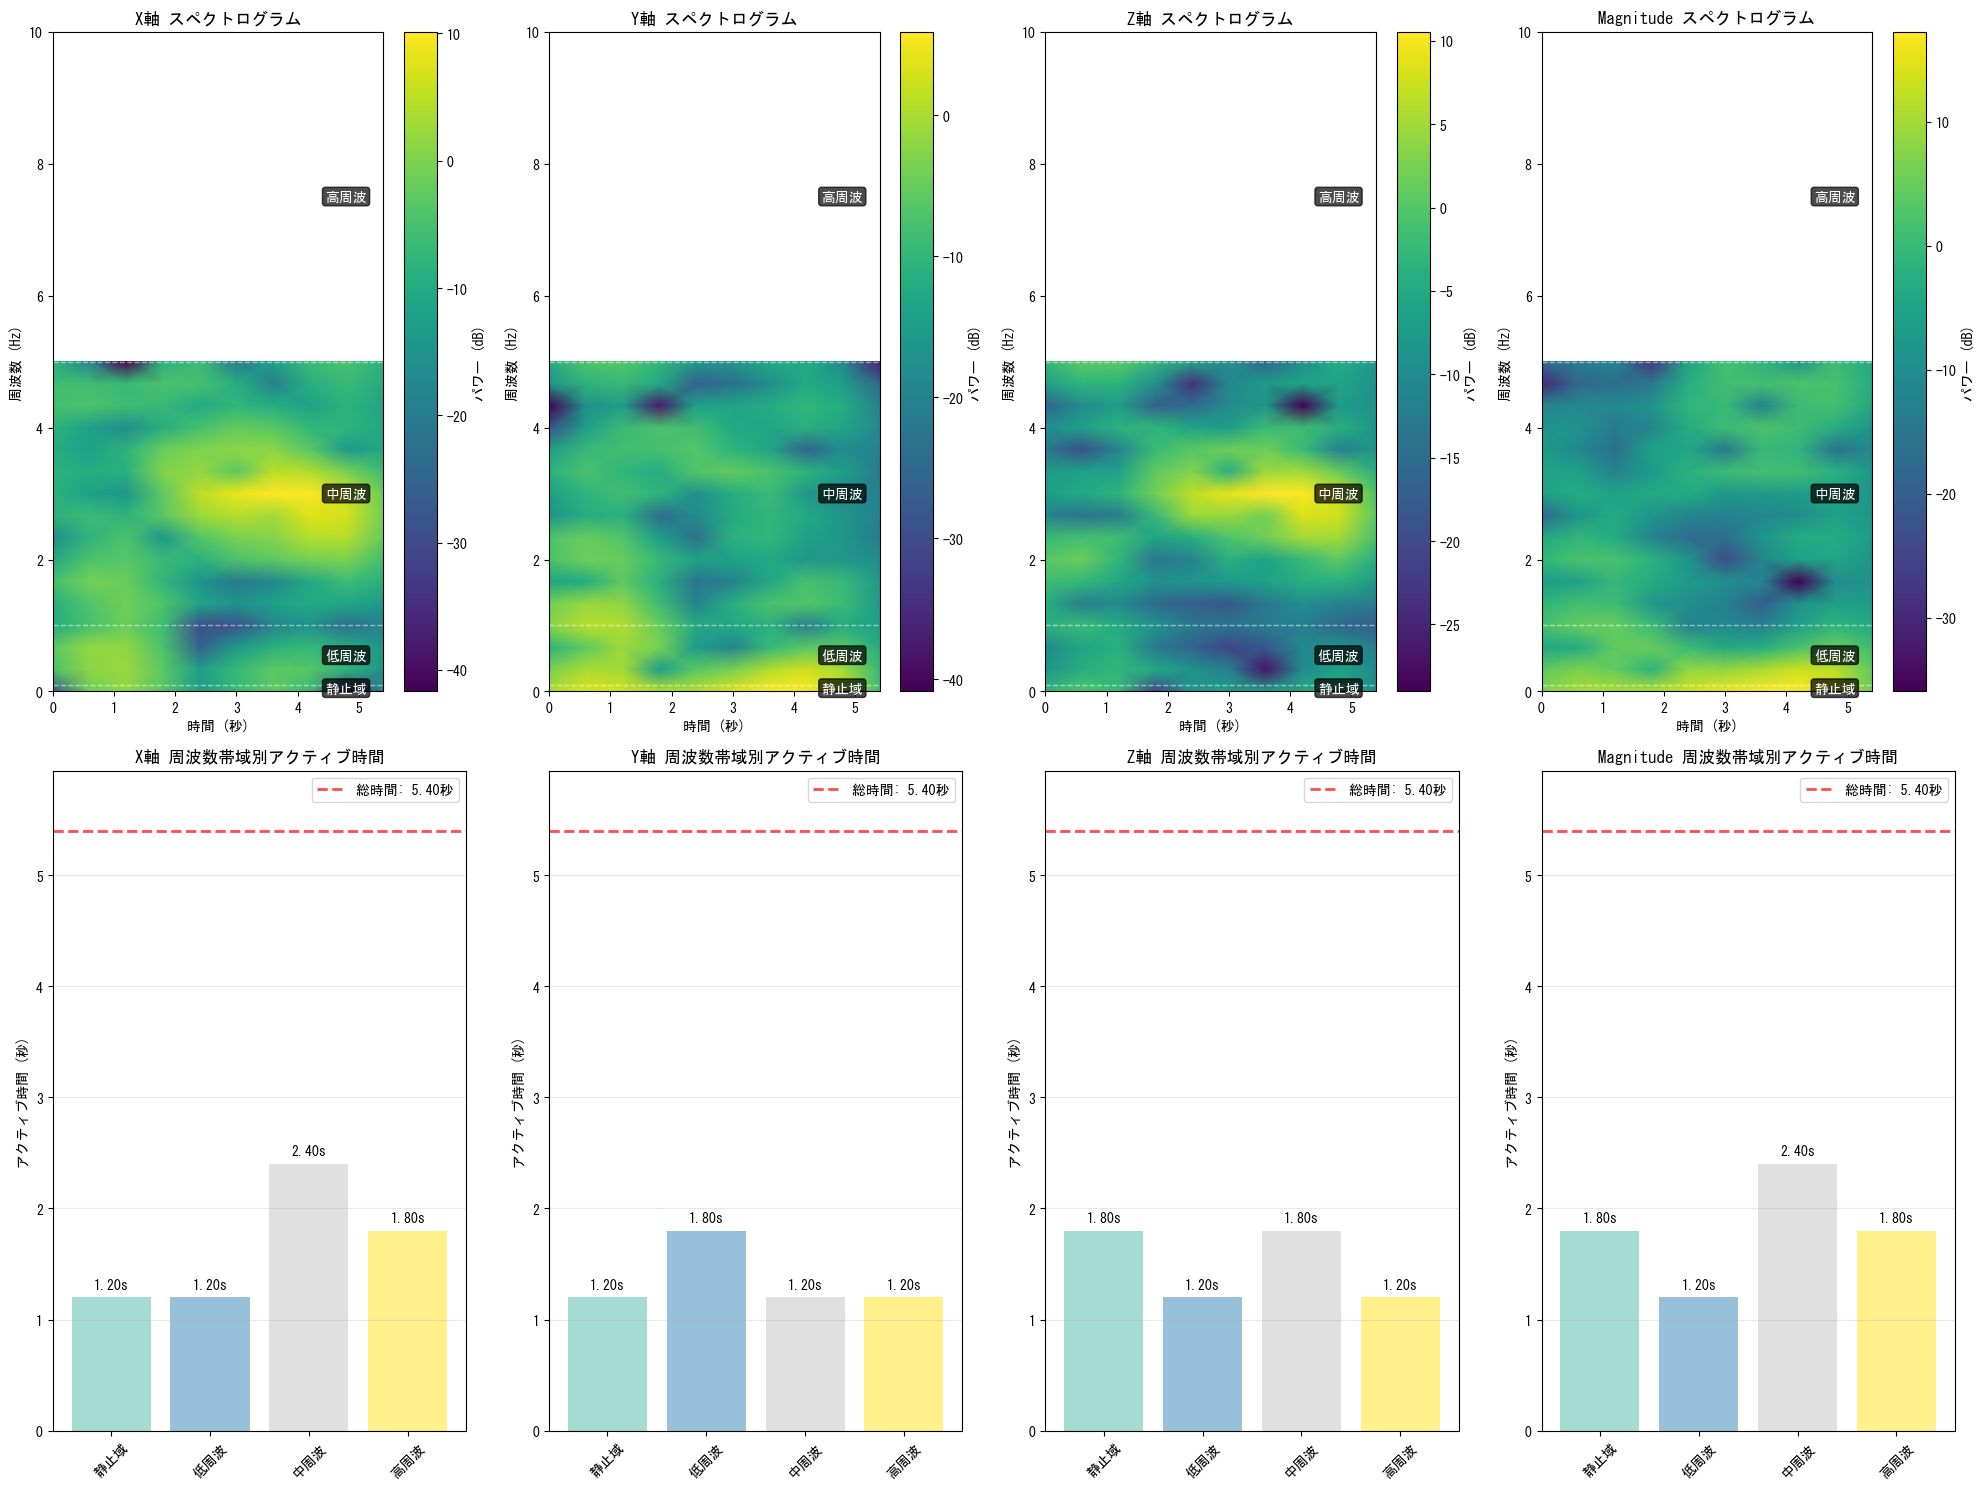

In [100]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

target_gesture = "Wave hello"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    visualize_frequency_time_analysis(train, target_sequences[10])

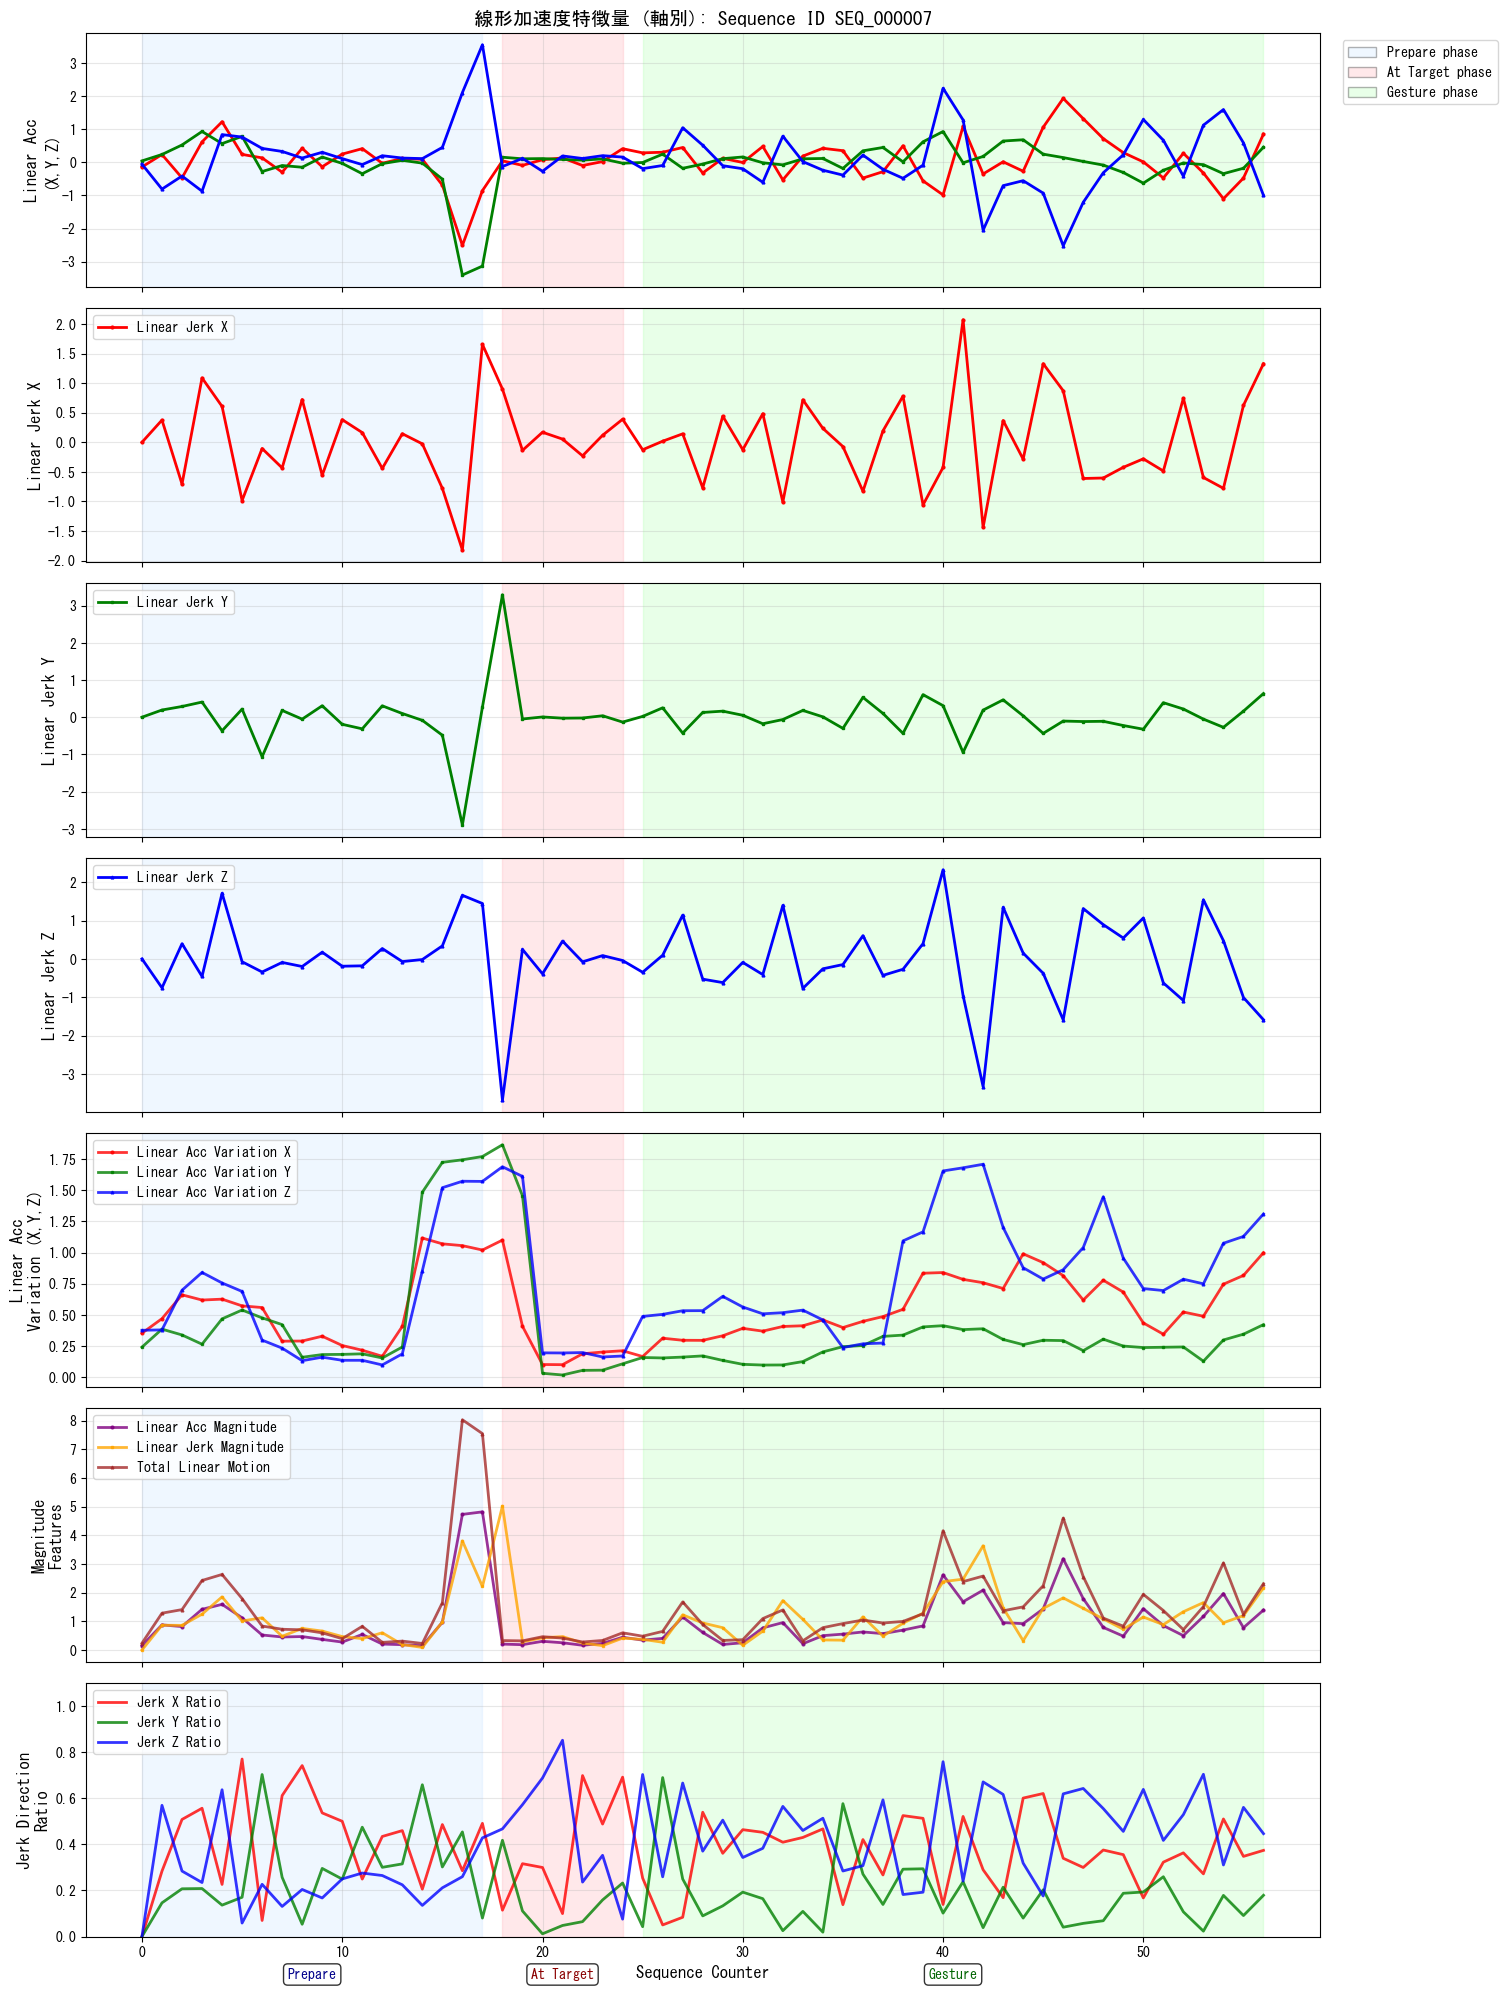

========== 線形加速度特徴量統計情報 (軸別) ==========
シーケンスID: SEQ_000007
被験者ID: SUBJ_059520
ジェスチャー: Cheek - pinch skin
方向: Seated Lean Non Dom - FACE DOWN
データポイント数: 57
フェーズ変化: Prepare → At Target → Gesture

📊 軸別Linear Jerk統計:
  Linear Jerk X:
    平均: 0.0174, 標準偏差: 0.7518
    最小: -1.8223, 最大: 2.0726
    絶対値平均: 0.5839
  Linear Jerk Y:
    平均: 0.0073, 標準偏差: 0.6703
    最小: -2.8980, 最大: 3.2908
    絶対値平均: 0.3461
  Linear Jerk Z:
    平均: -0.0166, 標準偏差: 1.0555
    最小: -3.6808, 最大: 2.3235
    絶対値平均: 0.7208

📊 軸別Linear Acceleration Variation統計:
  Linear Acc Variation X:
    平均: 0.5408, 標準偏差: 0.2807
    最小: 0.1019, 最大: 1.1159
  Linear Acc Variation Y:
    平均: 0.3964, 標準偏差: 0.4593
    最小: 0.0191, 最大: 1.8626
  Linear Acc Variation Z:
    平均: 0.7345, 標準偏差: 0.4936
    最小: 0.0997, 最大: 1.7067

📈 動作方向性分析:
  Jerk優勢度:
    X軸 (左右): 0.354 (35.4%)
    Y軸 (前後): 0.210 (21.0%)
    Z軸 (上下): 0.437 (43.7%)
    主要動作方向: Z軸 (上下)

📈 フェーズ別方向性分析:

  🔹 Prepare フェーズ:
    平均Jerk絶対値: X=0.6113, Y=0.4290, Z=0.4651
    主要動作方向: X軸 (左右) (40.

In [ ]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

target_gesture = "Cheek - pinch skin"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    plot_linear_acc_features_timeseries_xyz(train, target_sequences[0])
    # plot_motion_detection_analysis(train, target_sequences[4])

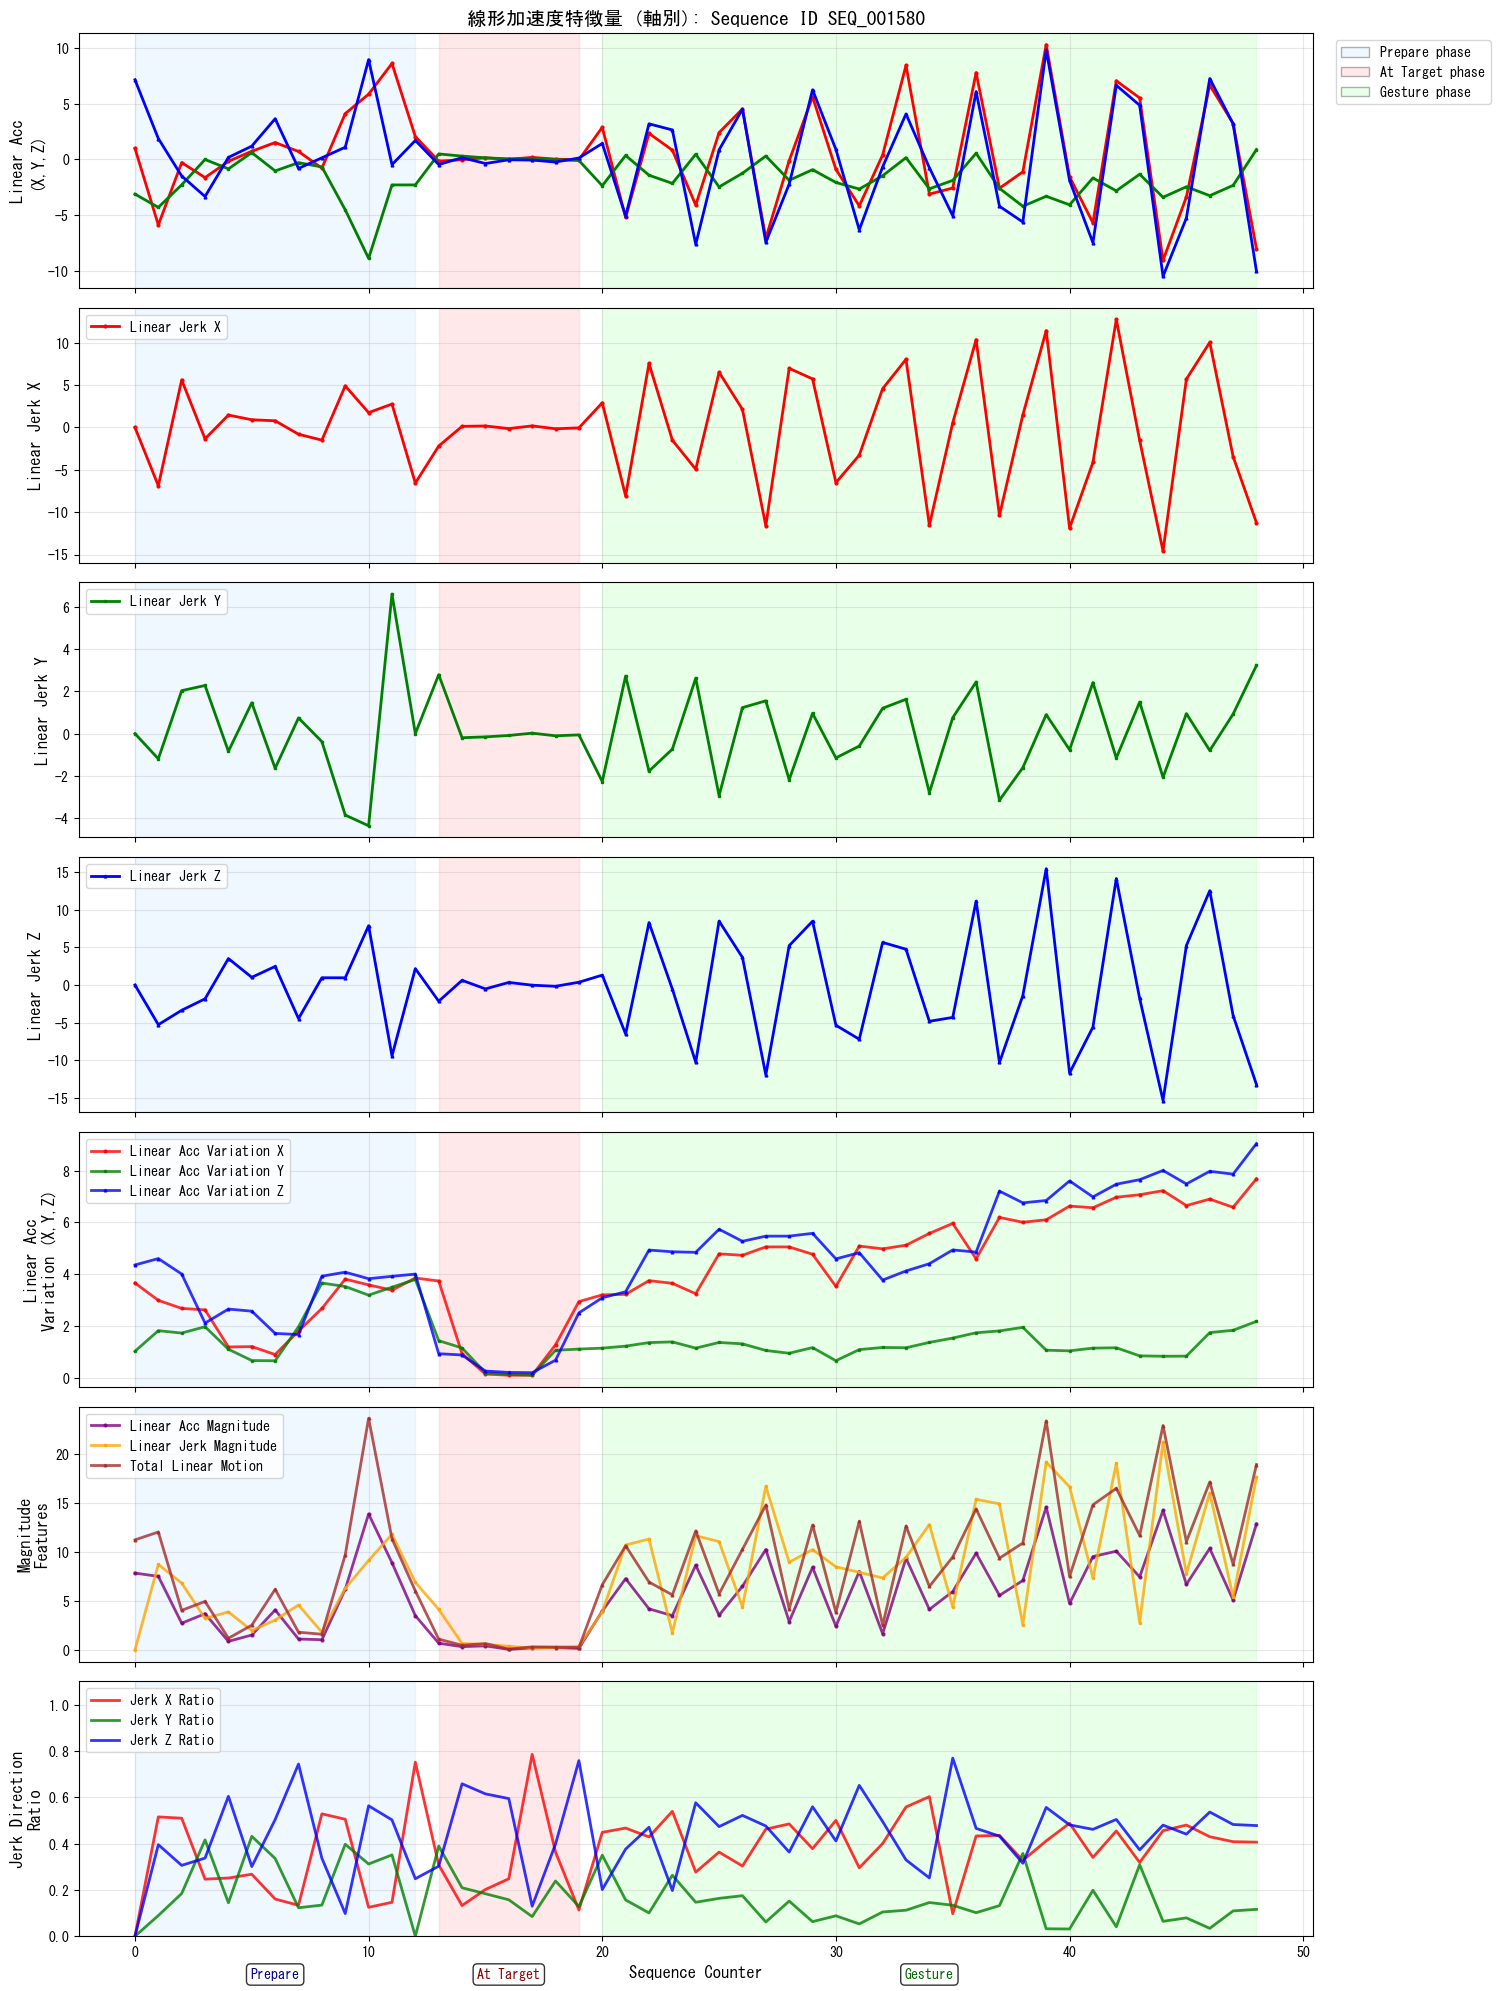

========== 線形加速度特徴量統計情報 (軸別) ==========
シーケンスID: SEQ_001580
被験者ID: SUBJ_001430
ジェスチャー: Wave hello
方向: Lie on Back
データポイント数: 49
フェーズ変化: Prepare → At Target → Gesture

📊 軸別Linear Jerk統計:
  Linear Jerk X:
    平均: -0.1843, 標準偏差: 6.4817
    最小: -14.5885, 最大: 12.7530
    絶対値平均: 4.8911
  Linear Jerk Y:
    平均: 0.0816, 標準偏差: 2.0578
    最小: -4.3578, 最大: 6.5933
    絶対値平均: 1.5854
  Linear Jerk Z:
    平均: -0.3512, 標準偏差: 7.0949
    最小: -15.3566, 最大: 15.4378
    絶対値平均: 5.4352

📊 軸別Linear Acceleration Variation統計:
  Linear Acc Variation X:
    平均: 4.0909, 標準偏差: 2.0826
    最小: 0.0930, 最大: 7.6902
  Linear Acc Variation Y:
    平均: 1.4454, 標準偏差: 0.8462
    最小: 0.0924, 最大: 3.7957
  Linear Acc Variation Z:
    平均: 4.4918, 標準偏差: 2.3199
    最小: 0.1915, 最大: 9.0529

📈 動作方向性分析:
  Jerk優勢度:
    X軸 (左右): 0.411 (41.1%)
    Y軸 (前後): 0.133 (13.3%)
    Z軸 (上下): 0.456 (45.6%)
    主要動作方向: Z軸 (上下)

📈 フェーズ別方向性分析:

  🔹 Prepare フェーズ:
    平均Jerk絶対値: X=2.7111, Y=1.9505, Z=3.3318
    主要動作方向: Z軸 (上下) (41.7%)

  🔹 At Target フェーズ

In [55]:
gesture_sequences = train.groupby('gesture')['sequence_id'].unique()

target_gesture = "Wave hello"
target_sequences = gesture_sequences.get(target_gesture, [])
if len(target_sequences) > 0:
    plot_linear_acc_features_timeseries_xyz(train, target_sequences[10])
    # plot_motion_detection_analysis(train, target_sequences[4])

In [28]:
def plot_linear_acceleration_features_comparison(data, gesture_name, orientation, behavior, num_sequences=3, figsize=(15, 10)):
    """
    特定のジェスチャー、方向、行動の線形加速度特徴量を複数シーケンス重ねて表示
    
    Parameters:
    -----------
    data : pandas.DataFrame
        データフレーム
    gesture_name : str
        表示するジェスチャー名
    orientation : str
        表示する方向
    behavior : str
        表示する行動
    num_sequences : int
        表示するシーケンス数（デフォルト: 3）
    figsize : tuple
        図のサイズ（デフォルト: (15, 10)）
    """
    
    # 指定された条件でデータを抽出
    filtered_data = data[
        (data['gesture'] == gesture_name) & 
        (data['orientation'] == orientation) & 
        (data['behavior'] == behavior)
    ]
    
    if len(filtered_data) == 0:
        print(f"❌ ジェスチャー '{gesture_name}', 方向 '{orientation}', 行動 '{behavior}' の条件に一致するデータが見つかりません")
        return
    
    # ユニークなsequence_idを取得
    unique_sequences = filtered_data['sequence_id'].unique()
    
    if len(unique_sequences) < num_sequences:
        print(f"⚠️ 指定された条件のシーケンスが{num_sequences}個未満です（{len(unique_sequences)}個）")
        num_sequences = len(unique_sequences)
    
    # 表示するシーケンスを選択
    sequences_to_plot = unique_sequences[:num_sequences]
    
    # behaviorの値をテキスト表記に変換するマッピング
    behavior_to_text = {
        'Relaxes and moves hand to target location': 'Prepare',
        'Moves hand to target location': 'Moving',
        'Hand at target location': 'At Target',
        'Performs gesture': 'Gesture',
    }
    behavior_text = behavior_to_text.get(behavior, behavior)
    
    # 各シーケンスに対して線形加速度特徴量を計算
    linear_features_sequences = {}
    
    for sequence_id in sequences_to_plot:
        seq_data = filtered_data[filtered_data['sequence_id'] == sequence_id].copy()
        seq_data = seq_data.sort_values('sequence_counter')
        
        # 線形加速度を計算
        if all(col in seq_data.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
            acc_data = seq_data[['acc_x', 'acc_y', 'acc_z']]
            rot_data = seq_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            linear_accel = remove_gravity_from_acc(acc_data, rot_data)
            
            seq_data['linear_acc_x'] = linear_accel[:, 0]
            seq_data['linear_acc_y'] = linear_accel[:, 1]
            seq_data['linear_acc_z'] = linear_accel[:, 2]
            seq_data['linear_acc_magnitude'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
            
            # calculate_linear_acc_features関数を使用
            features = calculate_linear_acc_features(seq_data)
            
            # 特徴量をデータフレームに追加
            for feature_name, feature_values in features.items():
                if len(feature_values) == len(seq_data):
                    seq_data[feature_name] = feature_values
            
            linear_features_sequences[sequence_id] = seq_data
    
    # プロット用の図を作成（4つのサブプロット）
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    fig.suptitle(f'{gesture_name} - {orientation} - {behavior_text}\n線形加速度特徴量比較', fontsize=16, fontweight='bold')
    
    # カラーパレット
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    # 各シーケンスをプロット
    for i, sequence_id in enumerate(sequences_to_plot):
        seq_data = linear_features_sequences[sequence_id]
        color = colors[i % len(colors)]
        
        # 1. 線形加速度の大きさ
        axes[0].plot(seq_data['sequence_counter'], seq_data['linear_acc_magnitude'], 
                    color=color, linewidth=2, alpha=0.7, label=f'Seq {i+1}')
        
        # 2. 線形Jerk（線形加速度の変化率）
        axes[1].plot(seq_data['sequence_counter'], seq_data['linear_jerk_magnitude'], 
                    color=color, linewidth=2, alpha=0.7, label=f'Seq {i+1}')
        
        # 3. 線形加速度の変動性
        axes[2].plot(seq_data['sequence_counter'], seq_data['linear_acc_variation'], 
                    color=color, linewidth=2, alpha=0.7, label=f'Seq {i+1}')
        
        # 4. 総線形動作量
        axes[3].plot(seq_data['sequence_counter'], seq_data['total_linear_motion'], 
                    color=color, linewidth=2, alpha=0.7, label=f'Seq {i+1}')
    
    # 軸の設定
    axes[0].set_ylabel('Linear Acc\nMagnitude', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].set_ylabel('Linear Jerk\nMagnitude', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[2].set_ylabel('Linear Acc\nVariation', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    axes[3].set_xlabel('sequence_counter', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Total Linear\nMotion', fontsize=12, fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 統計情報を表示
    print(f"\n📊 統計情報:")
    print(f"ジェスチャー: {gesture_name}")
    print(f"方向: {orientation}")
    print(f"行動: {behavior_text}")
    print(f"表示したシーケンス数: {len(sequences_to_plot)}")
    
    # 全データの統計
    all_linear_data = pd.concat(linear_features_sequences.values(), ignore_index=True)
    print(f"\n📈 線形加速度特徴量統計 (全シーケンス):")
    print(f"  Linear Acc Magnitude - 平均: {all_linear_data['linear_acc_magnitude'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_magnitude'].std():.4f}")
    print(f"  Linear Jerk Magnitude - 平均: {all_linear_data['linear_jerk_magnitude'].mean():.4f}, 標準偏差: {all_linear_data['linear_jerk_magnitude'].std():.4f}")
    print(f"  Linear Acc Variation - 平均: {all_linear_data['linear_acc_variation'].mean():.4f}, 標準偏差: {all_linear_data['linear_acc_variation'].std():.4f}")
    print(f"  Total Linear Motion - 平均: {all_linear_data['total_linear_motion'].mean():.4f}, 標準偏差: {all_linear_data['total_linear_motion'].std():.4f}")

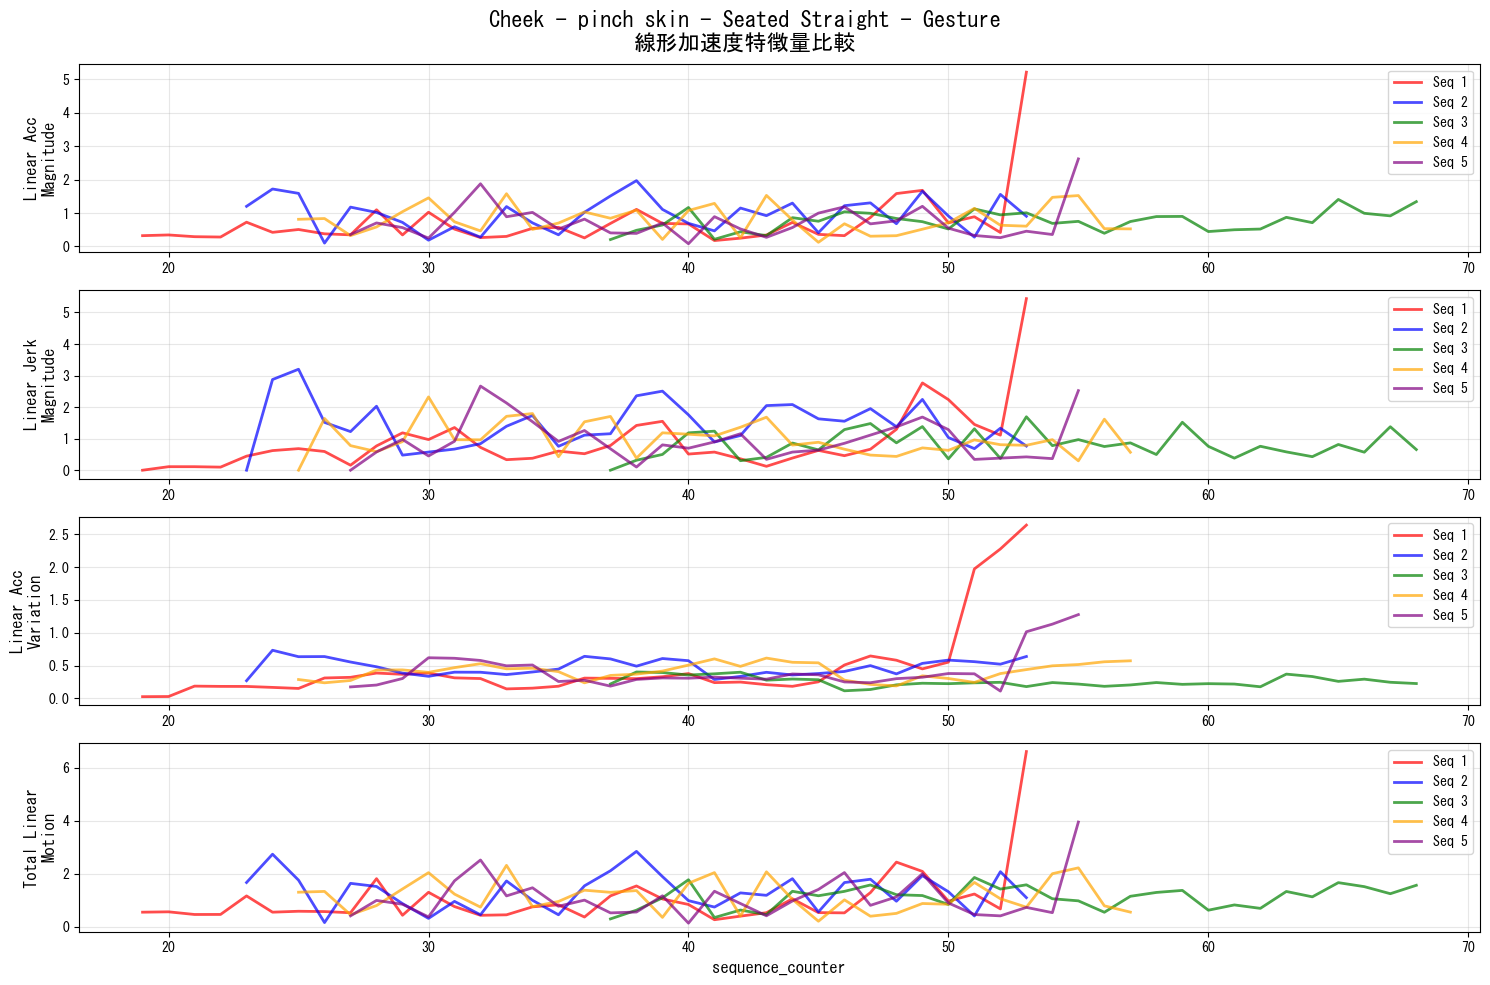


📊 統計情報:
ジェスチャー: Cheek - pinch skin
方向: Seated Straight
行動: Gesture
表示したシーケンス数: 5

📈 線形加速度特徴量統計 (全シーケンス):
  Linear Acc Magnitude - 平均: 0.7935, 標準偏差: 0.5582
  Linear Jerk Magnitude - 平均: 1.0170, 標準偏差: 0.7291
  Linear Acc Variation - 平均: 0.4065, 標準偏差: 0.3194
  Total Linear Motion - 平均: 1.1458, 標準偏差: 0.7559


In [29]:
plot_linear_acceleration_features_comparison(
    train, 
    gesture_name='Cheek - pinch skin', 
    orientation='Seated Straight', 
    # behavior='Relaxes and moves hand to target location',
    # behavior='Moves hand to target location',
    # behavior='Hand at target location',
    behavior='Performs gesture',
    num_sequences=5
)

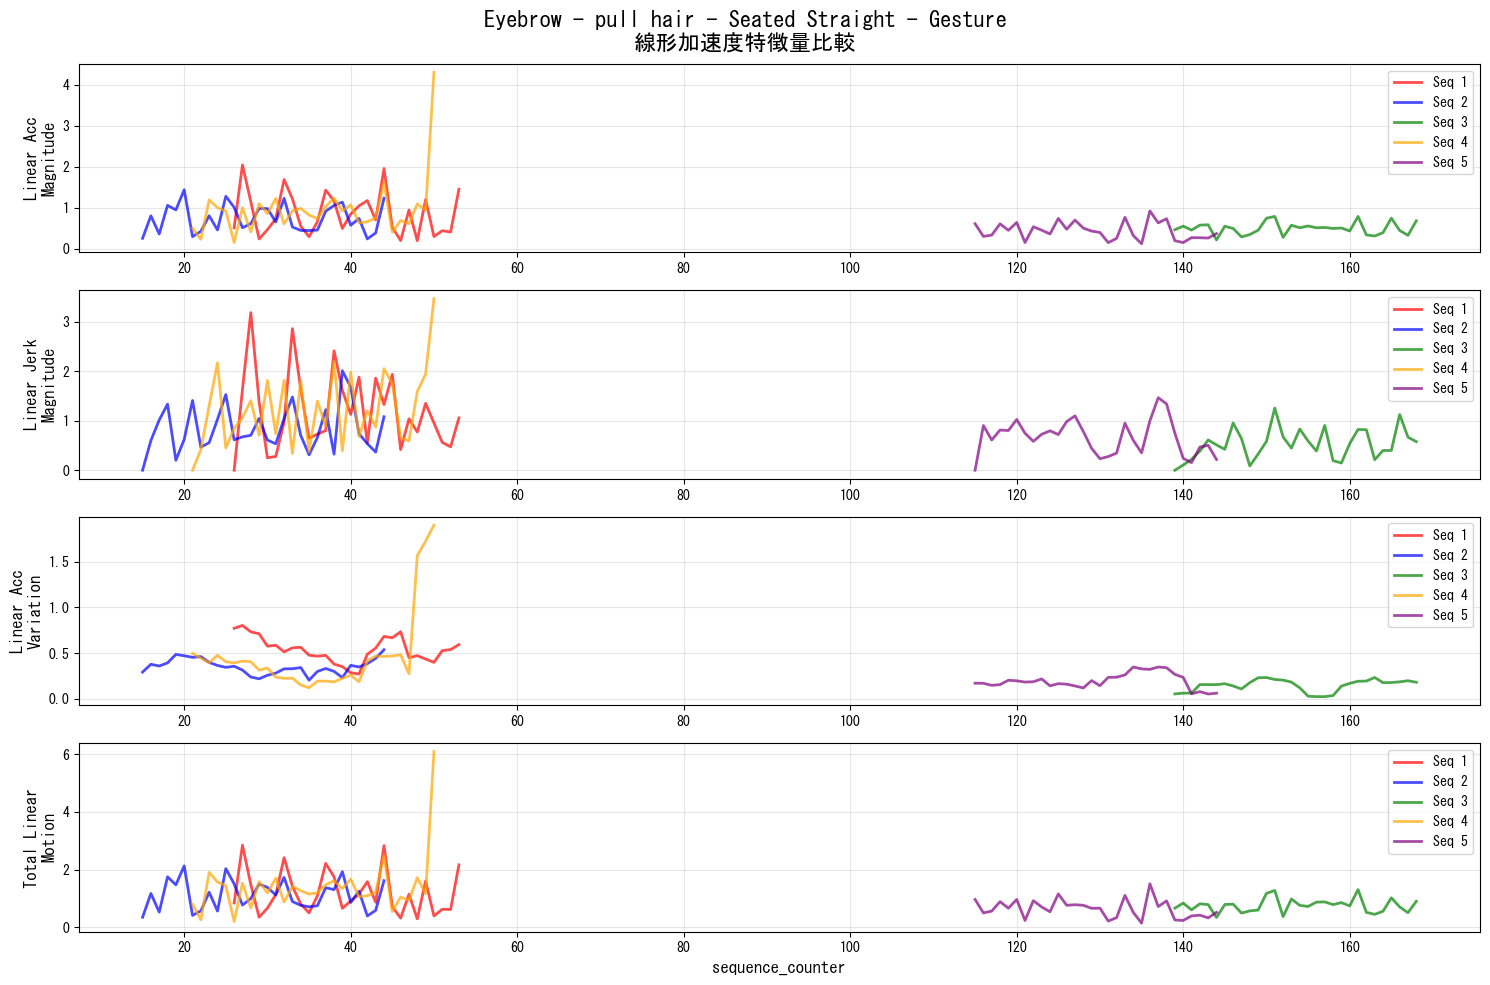


📊 統計情報:
ジェスチャー: Eyebrow - pull hair
方向: Seated Straight
行動: Gesture
表示したシーケンス数: 5

📈 線形加速度特徴量統計 (全シーケンス):
  Linear Acc Magnitude - 平均: 0.6929, 標準偏差: 0.4774
  Linear Jerk Magnitude - 平均: 0.8879, 標準偏差: 0.6285
  Linear Acc Variation - 平均: 0.3365, 標準偏差: 0.2632
  Total Linear Motion - 平均: 1.0201, 標準偏差: 0.6827


In [30]:
plot_linear_acceleration_features_comparison(
    train, 
    gesture_name='Eyebrow - pull hair', 
    orientation='Seated Straight', 
    # behavior='Relaxes and moves hand to target location',
    # behavior='Moves hand to target location',
    # behavior='Hand at target location',
    behavior='Performs gesture',
    num_sequences=5
)

In [14]:
def extract_imu_features(df: pd.DataFrame) -> dict:
    """
    IMUセンサ（加速度計・ジャイロスコープ）の特徴量を抽出する関数
    線形加速度と生データの両方から補完的な特徴量を抽出
    重力座標系での動き分析も含む
    """
    feats = {}
    
    # 基本的なIMU列の取得
    base_imu_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]

    # 高度なIMU特徴量の作成
    try:
        # 1. 重力除去による線形加速度（メイン特徴量）
        if all(col in df.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
            acc_data = df[['acc_x', 'acc_y', 'acc_z']]
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            linear_accel = remove_gravity_from_acc(acc_data, rot_data)
            
            # 線形加速度をメインとして使用
            df['linear_acc_x'] = linear_accel[:, 0]
            df['linear_acc_y'] = linear_accel[:, 1]
            df['linear_acc_z'] = linear_accel[:, 2]
            df['linear_acc_mag'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
            
            # 線形加速度のJerk（より重要）
            df['linear_acc_jerk_x'] = df['linear_acc_x'].diff().fillna(0)
            df['linear_acc_jerk_y'] = df['linear_acc_y'].diff().fillna(0)
            df['linear_acc_jerk_z'] = df['linear_acc_z'].diff().fillna(0)
            df['linear_acc_jerk_mag'] = np.sqrt(df['linear_acc_jerk_x']**2 + df['linear_acc_jerk_y']**2 + df['linear_acc_jerk_z']**2)
            
            # === 重力座標系での動き分析 ===
            # 線形加速度をグローバル座標系に変換
            quat_values = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
            global_acc = np.zeros_like(linear_accel)
            
            for i in range(len(linear_accel)):
                if not np.any(np.isnan(quat_values[i])) and not np.all(np.isclose(quat_values[i], 0)):
                    try:
                        rotation = R.from_quat(quat_values[i])
                        # ローカル座標系からグローバル座標系に変換
                        global_acc[i] = rotation.apply(linear_accel[i])
                    except ValueError:
                        global_acc[i] = linear_accel[i]
                else:
                    global_acc[i] = linear_accel[i]
            
            # グローバル座標系での特徴量をデータフレームに追加
            df['global_acc_x'] = global_acc[:, 0]  # グローバルX軸（左右方向）
            df['global_acc_y'] = global_acc[:, 1]  # グローバルY軸（前後方向）
            df['global_acc_z'] = global_acc[:, 2]  # グローバルZ軸（上下方向）
            df['global_acc_mag'] = np.sqrt(global_acc[:, 0]**2 + global_acc[:, 1]**2 + global_acc[:, 2]**2)
            
            # グローバル座標系でのJerk
            df['global_acc_jerk_x'] = df['global_acc_x'].diff().fillna(0)
            df['global_acc_jerk_y'] = df['global_acc_y'].diff().fillna(0)
            df['global_acc_jerk_z'] = df['global_acc_z'].diff().fillna(0)
            df['global_acc_jerk_mag'] = np.sqrt(df['global_acc_jerk_x']**2 + df['global_acc_jerk_y']**2 + df['global_acc_jerk_z']**2)
            
            # 方向別の動作強度比（重要な位置特徴量）
            total_motion = df['global_acc_mag'].values
            if np.mean(total_motion) > 1e-8:
                feats['vertical_motion_ratio'] = np.mean(np.abs(df['global_acc_z'])) / np.mean(total_motion)  # 上下動作の比率
                feats['horizontal_motion_ratio'] = np.mean(np.sqrt(df['global_acc_x']**2 + df['global_acc_y']**2)) / np.mean(total_motion)  # 水平動作の比率
                feats['lateral_motion_ratio'] = np.mean(np.abs(df['global_acc_x'])) / np.mean(total_motion)  # 左右動作の比率
                feats['forward_motion_ratio'] = np.mean(np.abs(df['global_acc_y'])) / np.mean(total_motion)  # 前後動作の比率
            else:
                feats['vertical_motion_ratio'] = 0
                feats['horizontal_motion_ratio'] = 0
                feats['lateral_motion_ratio'] = 0
                feats['forward_motion_ratio'] = 0
            
            # 重力座標系での方向優勢度
            global_acc_abs = np.abs(global_acc)
            if np.sum(global_acc_abs) > 1e-8:
                feats['x_dominance'] = np.sum(global_acc_abs[:, 0]) / np.sum(global_acc_abs)  # X軸優勢度
                feats['y_dominance'] = np.sum(global_acc_abs[:, 1]) / np.sum(global_acc_abs)  # Y軸優勢度
                feats['z_dominance'] = np.sum(global_acc_abs[:, 2]) / np.sum(global_acc_abs)  # Z軸優勢度
            else:
                feats['x_dominance'] = 0.33
                feats['y_dominance'] = 0.33
                feats['z_dominance'] = 0.33
            
            # メインIMU特徴量として線形加速度＋グローバル加速度を採用
            main_imu_cols = [
                'linear_acc_x', 'linear_acc_y', 'linear_acc_z', 'linear_acc_mag',
                'linear_acc_jerk_x', 'linear_acc_jerk_y', 'linear_acc_jerk_z', 'linear_acc_jerk_mag',
                'global_acc_x', 'global_acc_y', 'global_acc_z', 'global_acc_mag',
                'global_acc_jerk_x', 'global_acc_jerk_y', 'global_acc_jerk_z', 'global_acc_jerk_mag'
            ]
        else:
            # フォールバック: 生データを使用
            df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
            df['acc_jerk_x'] = df['acc_x'].diff().fillna(0)
            df['acc_jerk_y'] = df['acc_y'].diff().fillna(0)
            df['acc_jerk_z'] = df['acc_z'].diff().fillna(0)
            df['acc_jerk_mag'] = np.sqrt(df['acc_jerk_x']**2 + df['acc_jerk_y']**2 + df['acc_jerk_z']**2)
            
            main_imu_cols = ['acc_x', 'acc_y', 'acc_z', 'acc_mag', 'acc_jerk_x', 'acc_jerk_y', 'acc_jerk_z', 'acc_jerk_mag']

        # 2. 補完的特徴量として生データのMagnitudeも保持（姿勢情報用）
        df['raw_acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
        
        # 3. 回転関連は既存を維持
        df['rot_mag'] = np.sqrt(df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2)
        
        # 角速度計算
        if all(col in df.columns for col in ['rot_x', 'rot_y', 'rot_z', 'rot_w']):
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            angular_velocity = calculate_angular_velocity_from_quat(rot_data)
            
            df['angular_vel_x'] = angular_velocity[:, 0]
            df['angular_vel_y'] = angular_velocity[:, 1]
            df['angular_vel_z'] = angular_velocity[:, 2]
            df['angular_vel_mag'] = np.sqrt(angular_velocity[:, 0]**2 + angular_velocity[:, 1]**2 + angular_velocity[:, 2]**2)
            
            # 角度距離
            angular_distance = calculate_angular_distance(rot_data)
            df['angular_distance'] = angular_distance
            
            # 回転関連特徴量
            rotation_cols = [
                'rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag',
                'angular_vel_x', 'angular_vel_y', 'angular_vel_z', 'angular_vel_mag',
                'angular_distance'
            ]
        else:
            rotation_cols = ['rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag']

        # 全特徴量列を統合
        all_feature_cols = main_imu_cols + rotation_cols + ['raw_acc_mag']
        
        # 姿勢情報特徴量（重力方向に対する傾き）
        feats['gravity_dominance'] = np.mean(df['raw_acc_mag']) - np.mean(df['linear_acc_mag'])  # 重力成分の大きさ
        
    except Exception as e:
        print(f"高度なIMU特徴量作成でエラー: {e}")
        # フォールバック処理
        all_feature_cols = base_imu_cols

    # Feature Extraction for all IMU features
    for col in all_feature_cols:
        if col not in df.columns:
            continue
            
        arr = df[col].values
        
        if np.all(np.isnan(arr)) or len(arr) == 0:
            continue

        # 統計量特徴量
        feats[f'{col}_mean'] = np.nanmean(arr)
        feats[f'{col}_std'] = np.nanstd(arr)
        feats[f'{col}_min'] = np.nanmin(arr)
        feats[f'{col}_max'] = np.nanmax(arr)
        
        # 有効値での追加特徴量
        valid_arr = arr[~np.isnan(arr)]
        if len(valid_arr) > 1:
            # Rolling Window Features
            for window in [10, 20]:
                rolling_mean = df[col].rolling(window=window, min_periods=1).mean()
                feats[f'{col}_roll_mean_{window}_mean'] = rolling_mean.mean()

            # Frequency Domain Features
            fft_vals = rfft(valid_arr)
            fft_mags = np.abs(fft_vals)

            if len(fft_mags) > 1:
                # 従来の最大値
                feats[f'{col}_fft_max'] = np.max(fft_mags)
                
                # 改良: DC成分を除外した最大値
                feats[f'{col}_fft_max_no_dc'] = np.max(fft_mags[1:])  # DC(0Hz)を除外
                
                # 改良: 周波数帯域別の強度
                n_freq = len(fft_mags)
                feats[f'{col}_fft_low'] = np.mean(fft_mags[1:n_freq//4])    # 低周波
                feats[f'{col}_fft_mid'] = np.mean(fft_mags[n_freq//4:n_freq//2])  # 中周波
                feats[f'{col}_fft_high'] = np.mean(fft_mags[n_freq//2:])   # 高周波
                
                # 改良: 周波数分布の偏り
                feats[f'{col}_fft_centroid'] = np.sum(fft_mags * np.arange(len(fft_mags))) / np.sum(fft_mags)

    # 相関関係（線形加速度メイン＋グローバル座標系）
    correlation_pairs = [
        # 線形加速度間の相関（ローカル座標系）
        ('linear_acc_x', 'linear_acc_y'), ('linear_acc_x', 'linear_acc_z'), ('linear_acc_y', 'linear_acc_z'),
        # グローバル座標系での相関
        ('global_acc_x', 'global_acc_y'), ('global_acc_x', 'global_acc_z'), ('global_acc_y', 'global_acc_z'),
        # 線形加速度のJerk間の相関
        ('linear_acc_jerk_x', 'linear_acc_jerk_y'), ('linear_acc_jerk_x', 'linear_acc_jerk_z'), ('linear_acc_jerk_y', 'linear_acc_jerk_z'),
        # グローバルJerk間の相関
        ('global_acc_jerk_x', 'global_acc_jerk_y'), ('global_acc_jerk_x', 'global_acc_jerk_z'), ('global_acc_jerk_y', 'global_acc_jerk_z'),
        # 回転関連
        ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z'),
        ('angular_vel_x', 'angular_vel_y'), ('angular_vel_x', 'angular_vel_z'), ('angular_vel_y', 'angular_vel_z'),
        # 加速度と回転の関係
        ('linear_acc_mag', 'angular_vel_mag'), ('linear_acc_mag', 'rot_mag'),
        ('global_acc_mag', 'angular_vel_mag'), ('global_acc_mag', 'linear_acc_mag'),
        # 姿勢関連（補完情報）
        ('raw_acc_mag', 'linear_acc_mag'), ('raw_acc_mag', 'global_acc_mag')
    ]
    
    for (c1, c2) in correlation_pairs:
        if c1 in df.columns and c2 in df.columns:
            try:
                valid_mask = ~(np.isnan(df[c1]) | np.isnan(df[c2]))
                if valid_mask.sum() > 1:
                    corr_val = np.corrcoef(df[c1][valid_mask], df[c2][valid_mask])[0, 1]
                    feats[f'{c1}_{c2}_corr'] = corr_val if not np.isnan(corr_val) else 0
                else:
                    feats[f'{c1}_{c2}_corr'] = 0
            except:
                feats[f'{c1}_{c2}_corr'] = 0
    
    return feats